In [251]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importing raw data
X_train = pd.read_csv("train.csv",sep= ',' )
X_test = pd.read_csv('Test.csv',sep=',')
X_train
# change "date" dtype to datetime with format %Y/%m/%d
y= X_train['target']




In [252]:
X_train.columns

Index(['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min',
       'target_max', 'target_variance', 'target_count',
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
   

In [253]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [254]:
X_train.describe()

,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
count,30557.000000,30557.000000,30557.000000,3.055700e+04,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,...,23320.000000,23320.000000,23320.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000
mean,61.148045,29.025866,117.992234,7.983756e+03,125.831135,15.302326,70.552747,0.006004,9.321342,0.416886,...,35.590916,-123.697777,46.533951,923.231949,1711.793613,0.016227,1.254703,13.849040,-69.098594,23.100630
std,46.861309,33.119775,100.417713,4.863090e+04,146.581856,10.688573,18.807884,0.003787,9.343226,2.707990,...,18.955228,71.916036,14.594267,929.633988,1741.299304,0.027016,55.101250,18.004375,84.702355,24.786350
min,1.000000,1.000000,1.000000,0.000000e+00,2.000000,0.420044,5.128572,0.000139,-34.647879,-15.559646,...,0.000000,-179.880630,0.000000,0.000000,0.000000,0.000000,-105.367363,0.000000,-179.947422,0.000000
25%,25.000000,5.000000,60.000000,1.064920e+03,44.000000,7.666667,58.600002,0.003403,3.123071,-1.097864,...,19.451524,-165.882624,36.693094,0.000000,0.000000,0.000000,0.000000,0.000000,-161.726937,0.000000
50%,50.000000,15.000000,91.000000,2.395350e+03,72.000000,12.200000,74.099998,0.004912,8.478424,0.222092,...,37.918838,-156.637162,47.445010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,44.000000,155.000000,5.882550e+03,150.000000,19.900000,85.450001,0.007562,16.201563,1.772925,...,52.270055,-118.453598,57.438181,1861.674119,3393.541633,0.023829,62.245728,27.412303,0.000000,47.090635
max,815.000000,438.000000,999.000000,1.841490e+06,1552.000000,72.599998,100.000000,0.021615,37.437921,17.955124,...,66.111289,179.776125,79.631711,2112.522949,6478.550544,0.210483,77.355232,59.972710,179.813344,69.992363


In [255]:
import numpy as np

X_train = X_train.replace(0, np.nan)

import sweetviz as sv

# Generate report for X_train and target
report = sv.analyze([X_train, "Train Data"], target_feat='target')

# Show the report in the browser
report.show_html('sweetviz_report.html')

In [256]:
type(X_train['Date'][0])

str

In [257]:
X_train['Date'] = pd.to_datetime(X_train['Date'], format = '%Y-%m-%d')
X_test['Date'] = pd.to_datetime(X_test['Date'], format = '%Y-%m-%d')

In [258]:
import missingno as msno

In [259]:
X_train.isna().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    27680
L3_CH4_sensor_azimuth_angle     27680
L3_CH4_sensor_zenith_angle      27680
L3_CH4_solar_azimuth_angle      27680
L3_CH4_solar_zenith_angle       27680
Length: 82, dtype: int64

<Axes: >

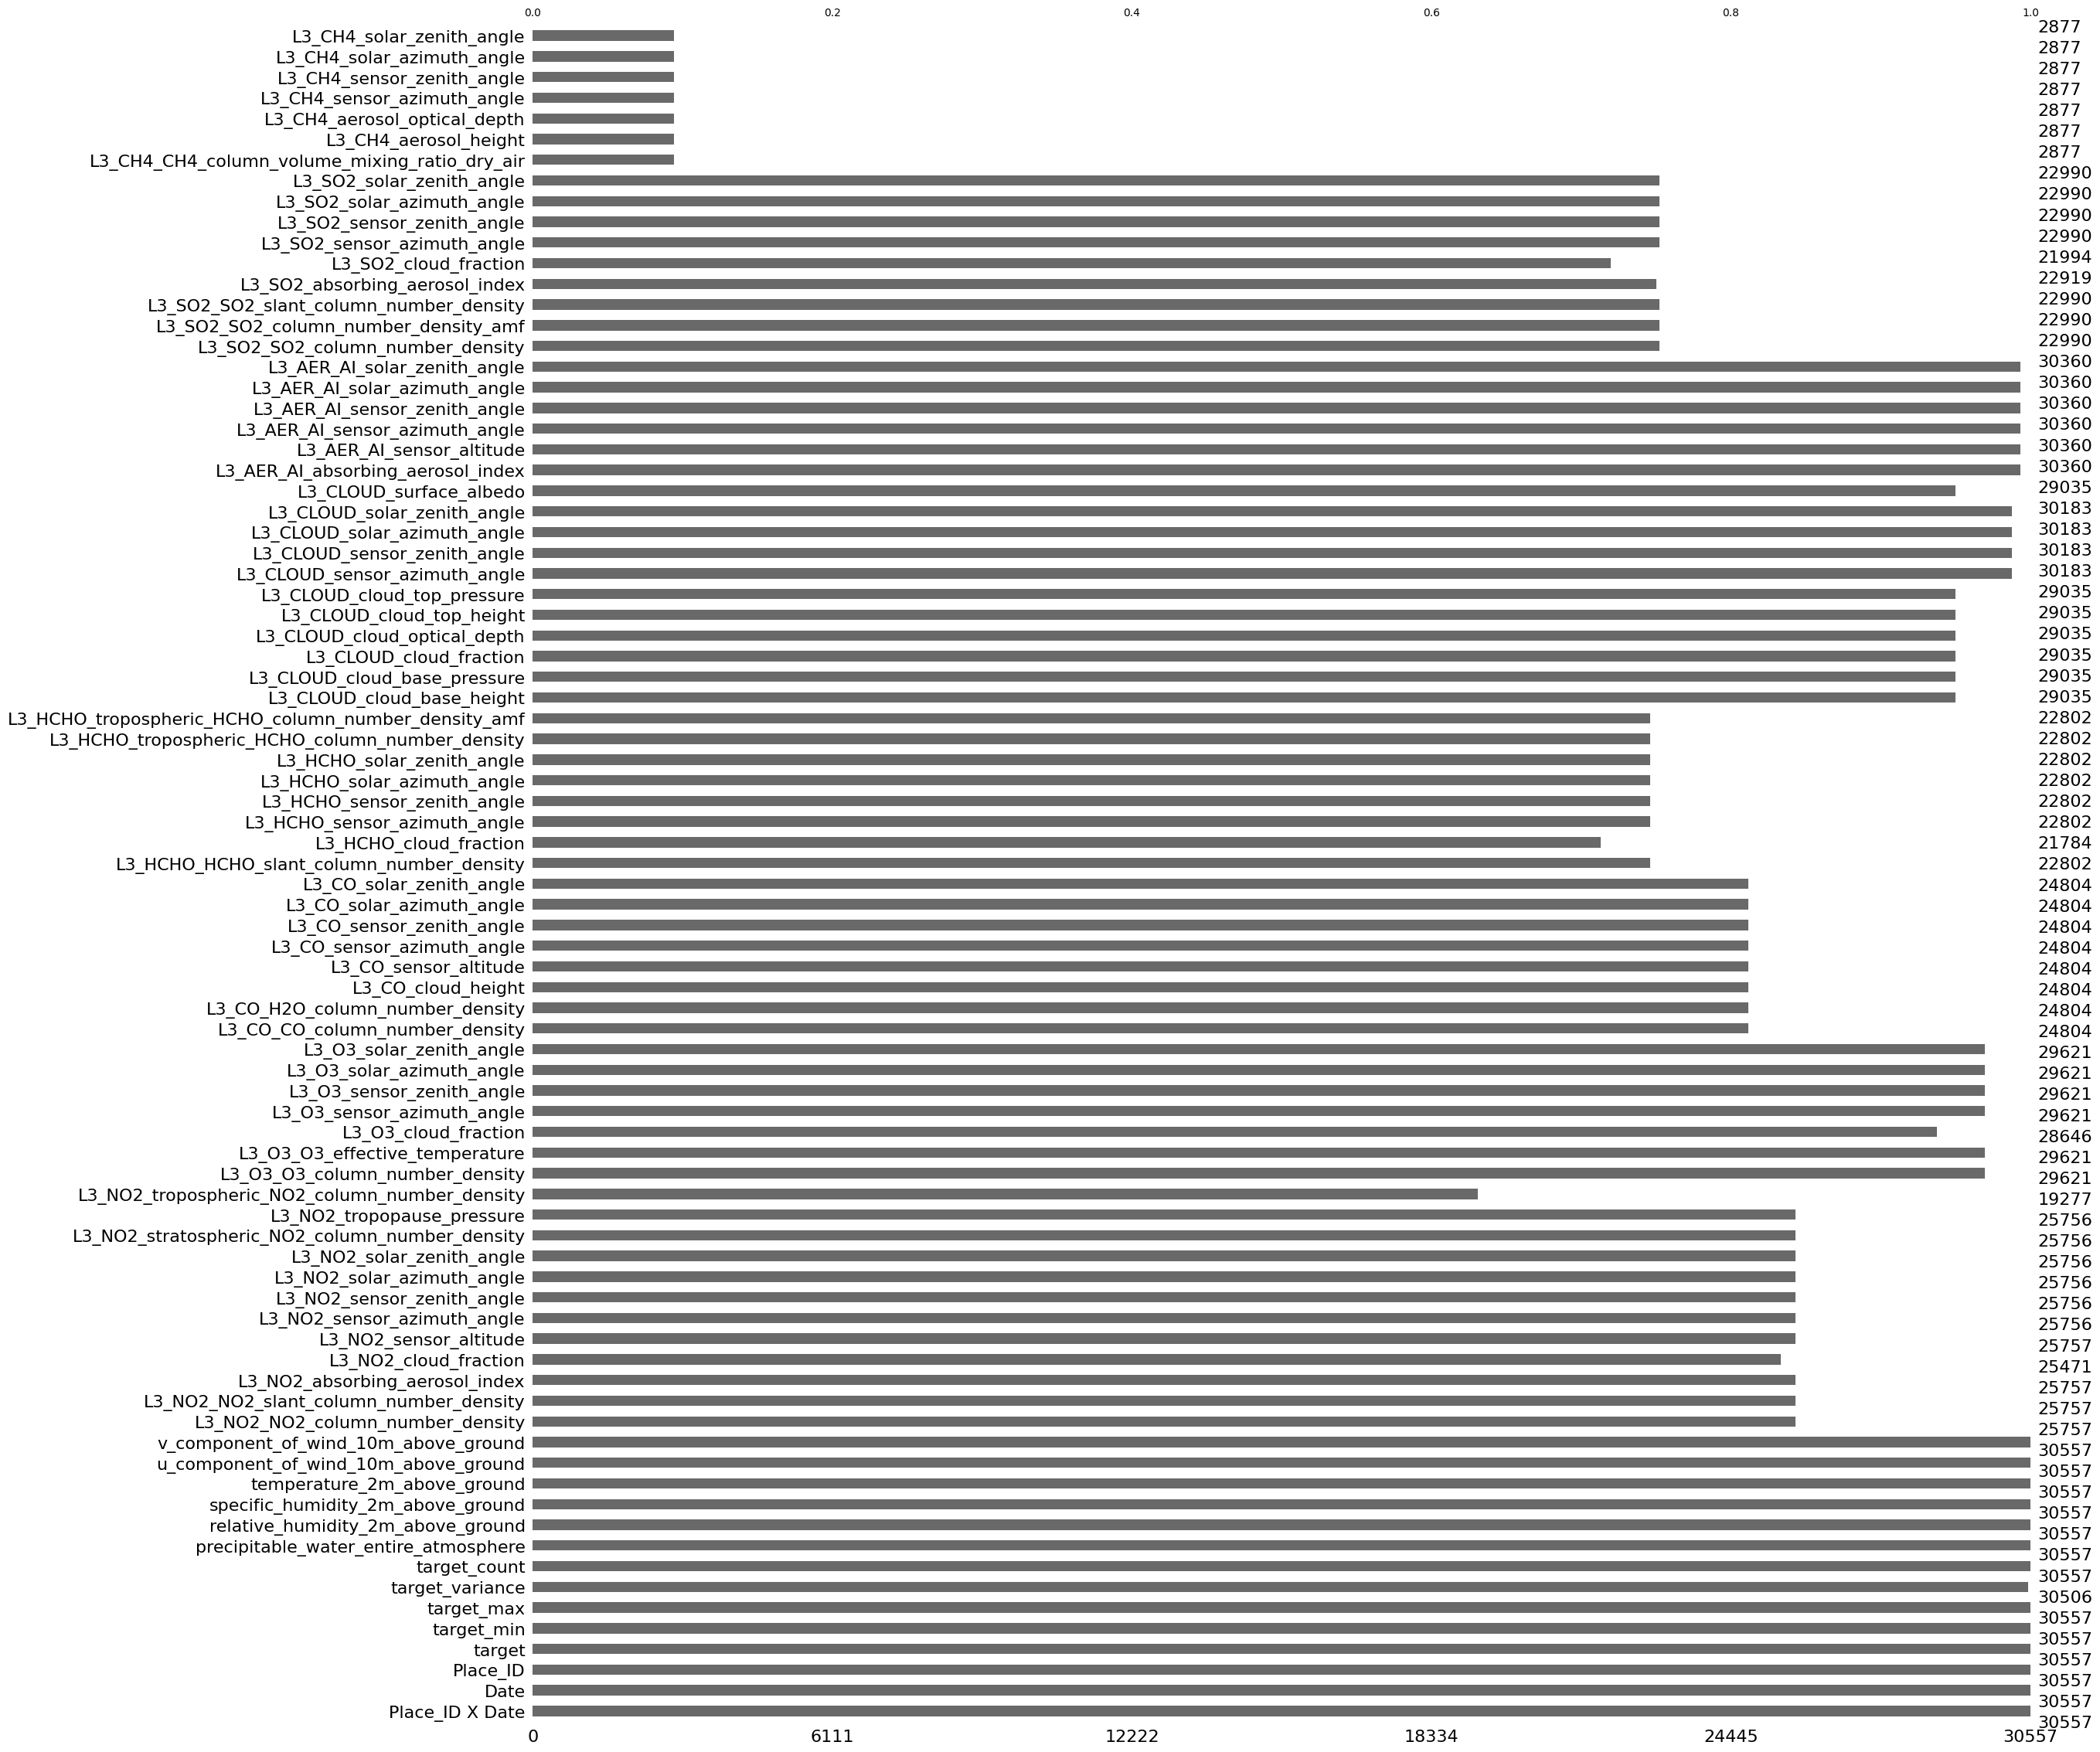

In [260]:
msno.bar(X_train)

<Axes: >

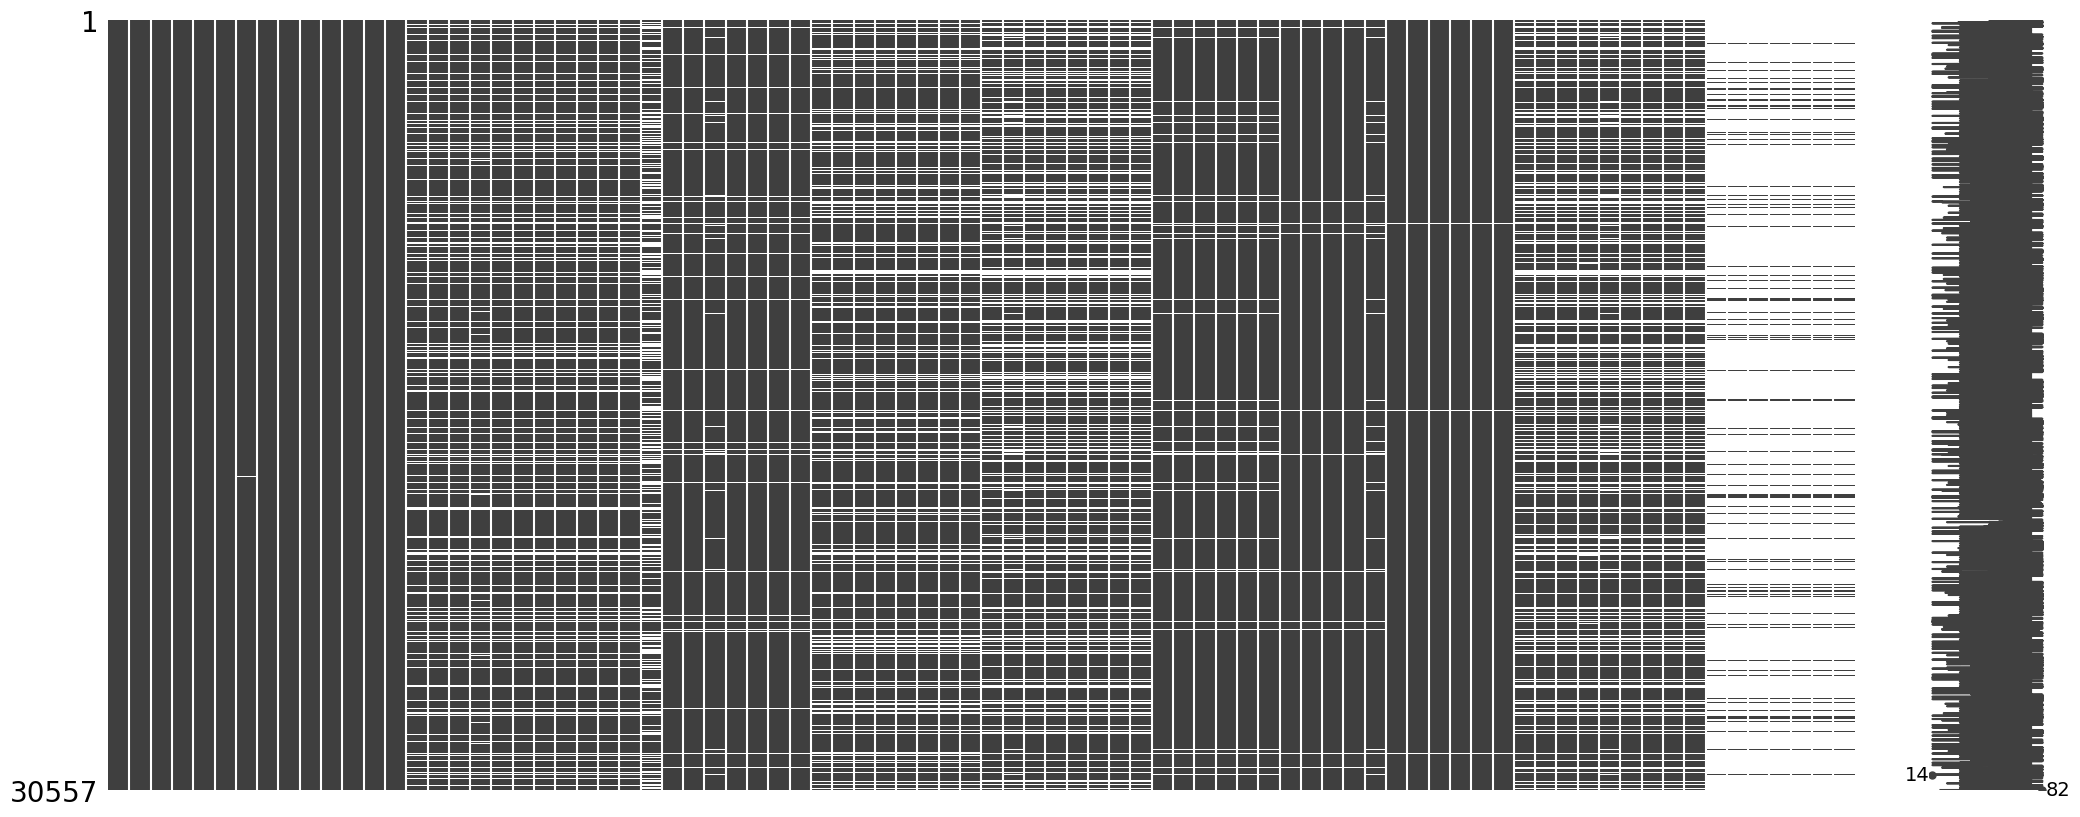

In [261]:
msno.matrix(X_train)

In [210]:
total_rows = len(X_train)
for col in X_train.columns:
    nan_count = X_train[col].isna().sum()
    nan_percent = (nan_count/total_rows)
    print(f"{col}:{nan_percent:.2f}% missing")

Place_ID X Date:0.00% missing
Date:0.00% missing
Place_ID:0.00% missing
target:0.00% missing
target_min:0.00% missing
target_max:0.00% missing
target_variance:0.00% missing
target_count:0.00% missing
precipitable_water_entire_atmosphere:0.00% missing
relative_humidity_2m_above_ground:0.00% missing
specific_humidity_2m_above_ground:0.00% missing
temperature_2m_above_ground:0.00% missing
u_component_of_wind_10m_above_ground:0.00% missing
v_component_of_wind_10m_above_ground:0.00% missing
L3_NO2_NO2_column_number_density:0.16% missing
L3_NO2_NO2_slant_column_number_density:0.16% missing
L3_NO2_absorbing_aerosol_index:0.16% missing
L3_NO2_cloud_fraction:0.17% missing
L3_NO2_sensor_altitude:0.16% missing
L3_NO2_sensor_azimuth_angle:0.16% missing
L3_NO2_sensor_zenith_angle:0.16% missing
L3_NO2_solar_azimuth_angle:0.16% missing
L3_NO2_solar_zenith_angle:0.16% missing
L3_NO2_stratospheric_NO2_column_number_density:0.16% missing
L3_NO2_tropopause_pressure:0.16% missing
L3_NO2_tropospheric_NO2_c

In [211]:
X_train.columns = X_train.columns.str.replace(" ", "_")

In [212]:
X_test = X_test.fillna(X_train.mean,  inplace=True)

In [213]:
X_train.isna().sum()

Place_ID_X_Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    27680
L3_CH4_sensor_azimuth_angle     27680
L3_CH4_sensor_zenith_angle      27680
L3_CH4_solar_azimuth_angle      27680
L3_CH4_solar_zenith_angle       27680
Length: 82, dtype: int64

In [214]:
import pandas as pd

# Set threshold for dropping columns (e.g., 60% missing)
threshold = 0.6

# Identify columns with >60% missing values
high_nan_cols = X_train.columns[X_train.isna().mean() > threshold]
print(f"Dropping {len(high_nan_cols)} columns due to high missingness (>60%):")
print(high_nan_cols.tolist())

# Drop those columns
X_train = X_train.drop(columns=high_nan_cols)
X_train = X_train.select_dtypes(include=[np.number])
# Fill remaining NaNs with median
X_train = X_train.fillna(X_train.mean())

# Optional: check that no NaNs remain
print("Remaining missing values per column:")
print(X_train.isna().sum())

Dropping 7 columns due to high missingness (>60%):
['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 'L3_CH4_aerosol_height', 'L3_CH4_aerosol_optical_depth', 'L3_CH4_sensor_azimuth_angle', 'L3_CH4_sensor_zenith_angle', 'L3_CH4_solar_azimuth_angle', 'L3_CH4_solar_zenith_angle']
Remaining missing values per column:
target                         0
target_min                     0
target_max                     0
target_variance                0
target_count                   0
                              ..
L3_SO2_cloud_fraction          0
L3_SO2_sensor_azimuth_angle    0
L3_SO2_sensor_zenith_angle     0
L3_SO2_solar_azimuth_angle     0
L3_SO2_solar_zenith_angle      0
Length: 72, dtype: int64


In [215]:
X_train.info

<bound method DataFrame.info of        target  target_min  target_max  target_variance  target_count   
0        38.0        23.0        53.0           769.50            92  \
1        39.0        25.0        63.0          1319.85            91   
2        24.0         8.0        56.0          1181.96            96   
3        49.0        10.0        55.0          1113.67            96   
4        21.0         9.0        52.0          1164.82            95   
...       ...         ...         ...              ...           ...   
30552    22.0        14.0        83.0          3848.86            72   
30553    53.0        30.0       146.0          9823.87            72   
30554    85.0        52.0       153.0          8900.85            72   
30555   103.0        33.0       149.0         13963.90            72   
30556    89.0        46.0       132.0          9393.64            72   

       precipitable_water_entire_atmosphere   
0                                 11.000000  \
1        

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = X_train.select_dtypes(include='number')
df_numeric.drop(['target_min','target_max','target_variance','target_count'], axis=1, inplace=True)

print(df_numeric)



       target  precipitable_water_entire_atmosphere   
0        38.0                             11.000000  \
1        39.0                             14.600000   
2        24.0                             16.400000   
3        49.0                              6.911948   
4        21.0                             13.900001   
...       ...                                   ...   
30552    22.0                              6.700000   
30553    53.0                              6.300000   
30554    85.0                              7.100000   
30555   103.0                             19.100000   
30556    89.0                             11.600000   

       relative_humidity_2m_above_ground  specific_humidity_2m_above_ground   
0                              60.200001                            0.00804  \
1                              48.799999                            0.00839   
2                              33.400002                            0.00750   
3                      

In [217]:
# Compute correlation with target
corr_with_target = df_numeric.corr()['target']

# Select features with absolute correlation > threshold (e.g., 0.2)
threshold = 0.2
important_features = corr_with_target[abs(corr_with_target) > threshold].index.tolist()



In [218]:
filtered_corr = df_numeric[important_features].corr()
print(filtered_corr)

                                                   target   
target                                           1.000000  \
L3_NO2_NO2_column_number_density                 0.291878   
L3_NO2_NO2_slant_column_number_density           0.314300   
L3_NO2_sensor_altitude                          -0.280214   
L3_NO2_tropospheric_NO2_column_number_density    0.242273   
L3_CO_CO_column_number_density                   0.364011   
L3_CO_sensor_altitude                           -0.272867   
L3_HCHO_HCHO_slant_column_number_density         0.285367   
L3_HCHO_tropospheric_HCHO_column_number_density  0.309293   
L3_AER_AI_sensor_altitude                       -0.307659   

                                                 L3_NO2_NO2_column_number_density   
target                                                                   0.291878  \
L3_NO2_NO2_column_number_density                                         1.000000   
L3_NO2_NO2_slant_column_number_density                                   

In [219]:


import plotly.express as px

fig = px.imshow(filtered_corr, 
                text_auto=True,  
                height = 1000, width = 1000,
                color_continuous_midpoint = 0.0,
                range_color=[-1, 1],
                title="Correlation Matrix")

fig.show()

Temperature-only Mean Baseline Metrics:
Mean of target: 9.3213
MSE: 87.2930
RMSE: 9.3431
MAE: 7.5033
R²: 0.0000


<Figure size 1600x600 with 0 Axes>

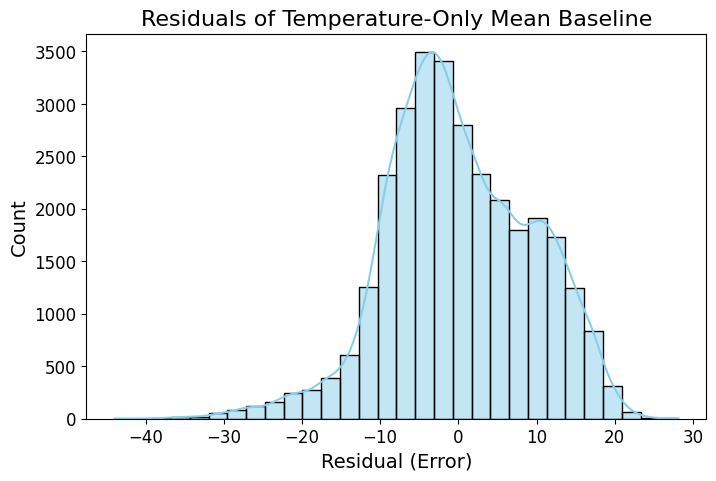

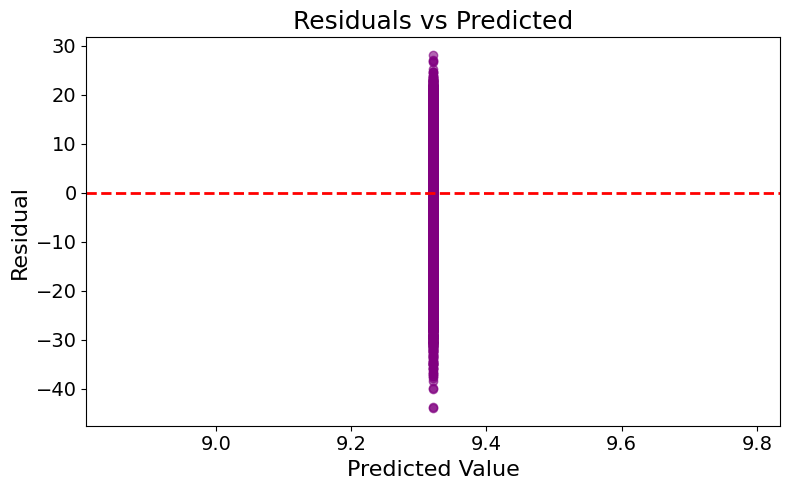

In [220]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt




data = X_train.copy()
y_true = data['temperature_2m_above_ground']  # target values (e.g., temperature to predict)

# Simple mean baseline prediction
mean_value = y_true.mean()
y_pred = [mean_value] * len(y_true)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Temperature-only Mean Baseline Metrics:")
print(f"Mean of target: {mean_value:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# -----------------------------
#  Residuals
# -----------------------------
residuals = y_true - y_pred

# -----------------------------
#  Plots with larger font
# -----------------------------
plt.figure(figsize=(16,6))
fontsize = 16  # set global font size



# Histogram of Residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black', stat="count")
plt.xlabel('Residual (Error)', fontsize=14)
plt.ylabel('Count', fontsize=14)  # now y-axis shows counts
plt.title('Residuals of Temperature-Only Mean Baseline', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Value', fontsize=fontsize)
plt.ylabel('Residual', fontsize=fontsize)
plt.title('Residuals vs Predicted', fontsize=fontsize+2)

# Tick label size
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

plt.tight_layout()
plt.show()

Rolling Mean (3-day lag) Baseline Metrics:
RMSE: 28.0360
MAE: 17.9305
R²: 0.6421


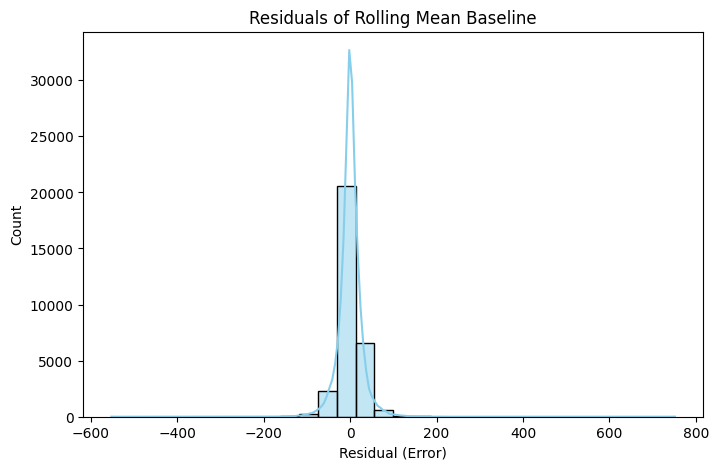

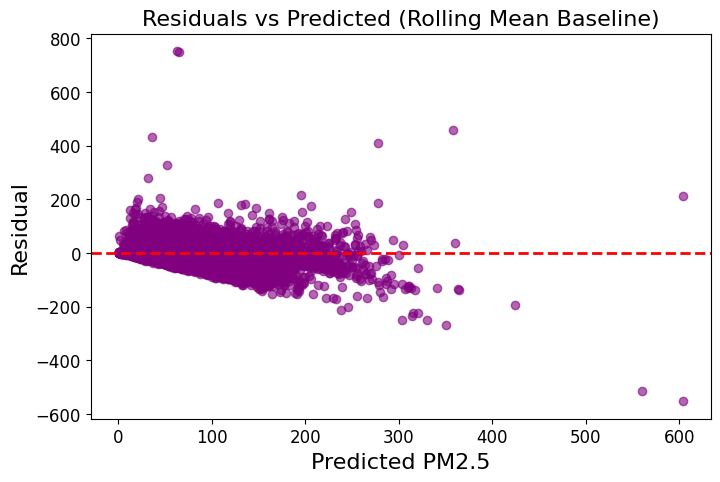

In [221]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt





data = X_train.copy()
y_true = data['target']

# ----------------------------
#  Rolling mean baseline (3-day lag) “Predict today using the average of the last 3 days (excluding today)”
# ----------------------------
y_pred = y_true.shift(1).rolling(3).mean()
mean_value = y_true.mean()  # fill first few NaNs with global mean
y_pred = y_pred.fillna(mean_value)

# ----------------------------
#  Compute metrics
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Rolling Mean (3-day lag) Baseline Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# ----------------------------
#  Residuals
# ----------------------------
residuals = y_true - y_pred

# Histogram
plt.figure(figsize=(8,5))
fontsize = 16  # set global font size
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black', stat="count")
plt.xlabel('Residual (Error)')
plt.ylabel('Count')
plt.title('Residuals of Rolling Mean Baseline')
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted PM2.5', fontsize=fontsize)
plt.ylabel('Residual', fontsize=fontsize)
plt.title('Residuals vs Predicted (Rolling Mean Baseline)',fontsize=fontsize)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Metrics on training data:
RMSE: 25.1799
MAE: 15.7699
R²: 0.7113


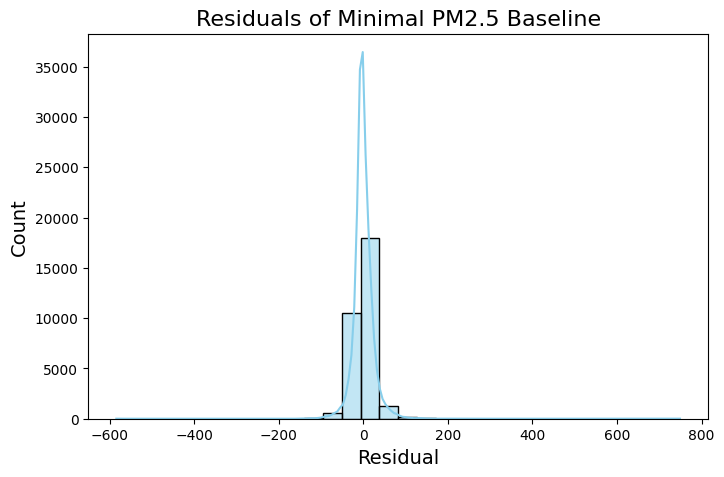

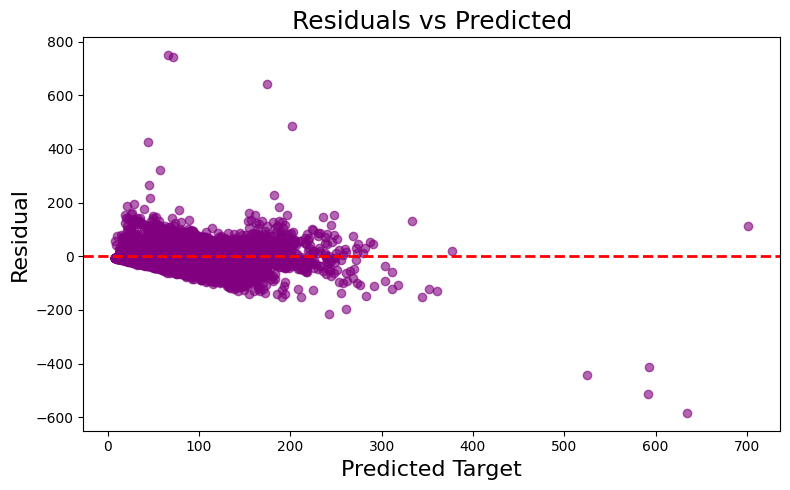

        Date  target  predicted_target
3 2020-01-05    49.0         30.734418
4 2020-01-06    21.0         48.471317
5 2020-01-07    28.0         27.439718
6 2020-01-08    21.0         34.806665
7 2020-01-09    18.0         26.120763


In [222]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️ Load training dataset
# ----------------------------
data = pd.read_csv("Train.csv", parse_dates=['Date'])

# ----------------------------
# 2️ Create minimal lagged features
# ----------------------------
data['PM2.5_lag_1'] = data['target'].shift(1)
data['PM2.5_lag_2'] = data['target'].shift(2)
data['PM2.5_roll_3'] = data['target'].shift(1).rolling(3).mean()
data['day_of_week'] = data['Date'].dt.dayofweek

lag_cols = ['PM2.5_lag_1', 'PM2.5_lag_2', 'PM2.5_roll_3', 'day_of_week']

# Drop rows with NaN due to lagging
df_model = data.dropna(subset=lag_cols + ['target'])

# ----------------------------
# 3️ Prepare features and target
# ----------------------------
X_lr = df_model[lag_cols]
y_lr = df_model['target']

# ----------------------------
# 4️ Train Linear Regression
# ----------------------------
model = LinearRegression()
model.fit(X_lr, y_lr)

# ----------------------------
# 5Predict on the same dataset
# ----------------------------
df_model['predicted_target'] = model.predict(X_lr)

# ----------------------------
# 6️ Compute metrics
# ----------------------------
residuals = df_model['target'] - df_model['predicted_target']
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
r2 = model.score(X_lr, y_lr)

print("Metrics on training data:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# ----------------------------
#  Residual plots
# ----------------------------
fontsize = 16

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Residual', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Residuals of Minimal PM2.5 Baseline', fontsize=16)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df_model['predicted_target'], residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Target', fontsize=fontsize)
plt.ylabel('Residual', fontsize=fontsize)
plt.title('Residuals vs Predicted', fontsize=fontsize+2)
plt.tight_layout()
plt.show()

# ----------------------------
# 8 Show predicted vs actual
# ----------------------------
print(df_model[['Date', 'target', 'predicted_target']].head())

Training Metrics:
RMSE: 43.52
MSE: 1894.21
MAE: 31.92
R²: 0.14


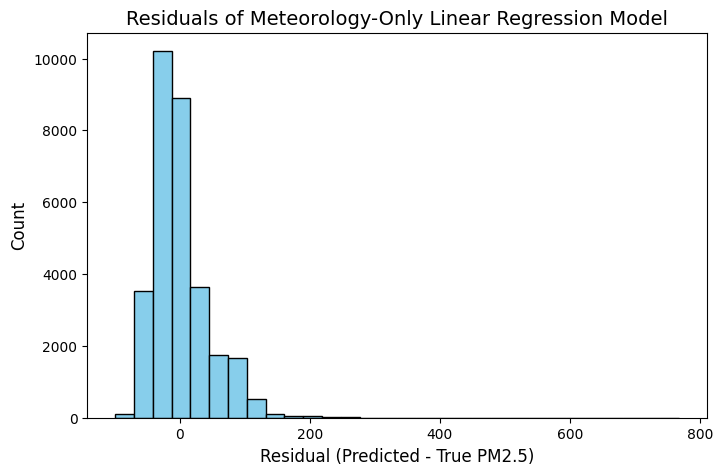

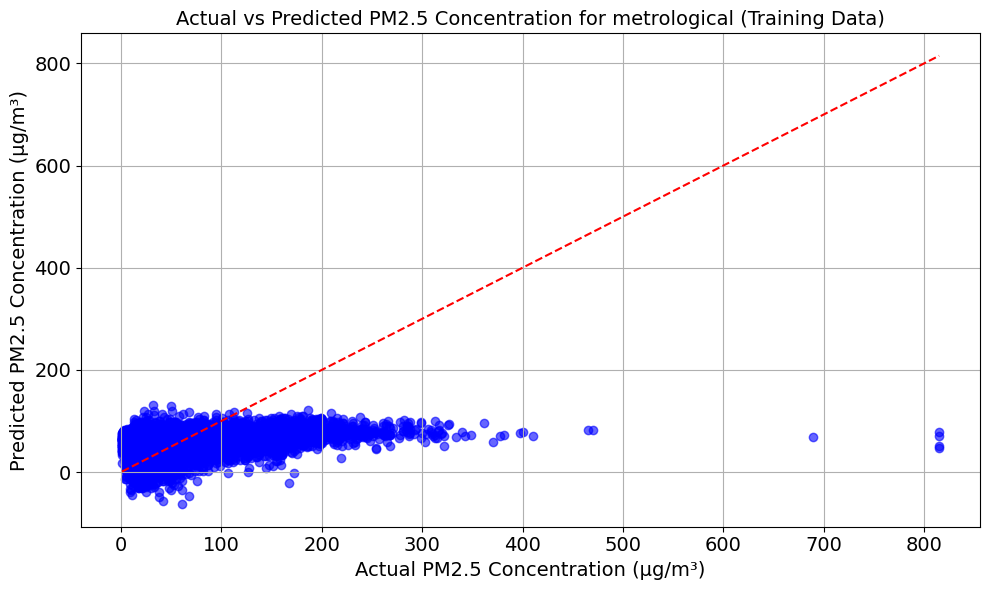

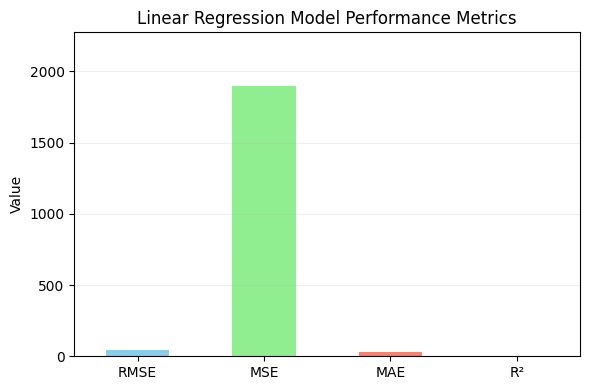

Feature Importance (Linear Regression Coefficients):
specific_humidity_2m_above_ground       2913.554383
precipitable_water_entire_atmosphere       0.116048
temp_humidity                             -0.020075
temperature_2m_above_ground               -0.065487
relative_humidity_2m_above_ground         -0.296992
v_component_of_wind_10m_above_ground      -0.320835
u_component_of_wind_10m_above_ground      -0.961737
wind_speed                                -6.559577
dtype: float64


In [223]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load X_train and X_test (Make sure X_train contains 'target')
# -----------------------------
X_train = pd.read_csv('Train.csv', sep=',')  # Replace with your file path
X_test = pd.read_csv('Test.csv', sep=',')  # Replace with your file path
X_train = X_train.replace(0, np.nan)
# Set threshold for dropping columns (e.g., 60% missing)
threshold = 0.6

# Identify columns with >60% missing values
high_nan_cols = X_train.columns[X_train.isna().mean() > threshold]


# Drop those columns
X_train = X_train.drop(columns=high_nan_cols)
X_train = X_train.select_dtypes(include=[np.number])
# Fill remaining NaNs with median
X_train = X_train.fillna(X_train.mean())
# Select features (X) and target (y) for training
X_train_selected = X_train[['precipitable_water_entire_atmosphere',
                            'relative_humidity_2m_above_ground',
                            'specific_humidity_2m_above_ground',
                            'temperature_2m_above_ground',
                            'u_component_of_wind_10m_above_ground',
                            'v_component_of_wind_10m_above_ground']]

y_train = X_train['target']  # Replace 'target' if necessary

# -----------------------------
# Fill missing values with mean for both X_train and X_test
# -----------------------------
X_train_selected = X_train_selected.fillna(X_train_selected.mean())
X_test_selected = X_test[['precipitable_water_entire_atmosphere',
                          'relative_humidity_2m_above_ground',
                          'specific_humidity_2m_above_ground',
                          'temperature_2m_above_ground',
                          'u_component_of_wind_10m_above_ground',
                          'v_component_of_wind_10m_above_ground']]

X_test_selected = X_test_selected.fillna(X_test_selected.mean())

# -----------------------------
# Feature engineering for X_train
# -----------------------------
X_train_selected['temp_humidity'] = X_train_selected['temperature_2m_above_ground'] * X_train_selected['relative_humidity_2m_above_ground']
X_train_selected['wind_speed'] = np.sqrt(X_train_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_train_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Feature engineering for X_test
# -----------------------------
X_test_selected['temp_humidity'] = X_test_selected['temperature_2m_above_ground'] * X_test_selected['relative_humidity_2m_above_ground']
X_test_selected['wind_speed'] = np.sqrt(X_test_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_test_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Train linear regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_selected, y_train)

# -----------------------------
# Predict on training data
# -----------------------------
y_train_pred = model.predict(X_train_selected)

# -----------------------------
# Predict on X_test data (no target in X_test)
# -----------------------------
y_test_pred = model.predict(X_test_selected)

# -----------------------------
# Metrics for training data
# -----------------------------
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)  # RMSE
mse_train = mean_squared_error(y_train, y_train_pred)  # MSE
mae_train = mean_absolute_error(y_train, y_train_pred)  # MAE
r2_train = r2_score(y_train, y_train_pred)  # R²

# Print training metrics
print(f"Training Metrics:")
print(f"RMSE: {rmse_train:.2f}")
print(f"MSE: {mse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R²: {r2_train:.2f}")

# -----------------------------
# Residual histogram (for training data)
# -----------------------------
residuals = y_train - y_train_pred
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Meteorology-Only Linear Regression Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# Actual vs Predicted Plot for Training Data
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(y_train, y_train_pred, color='blue', label='Actual vs Predicted (Train)', alpha=0.6)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual PM2.5 Concentration (µg/m³)', fontsize=14)
plt.ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Actual vs Predicted PM2.5 Concentration for metrological (Training Data)', fontsize=14)
#plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Metrics Bar Plot for Training Data
# -----------------------------
metrics = pd.Series({'RMSE': rmse_train, 'MSE': mse_train, 'MAE': mae_train, 'R²': r2_train})
plt.figure(figsize=(6,4))
metrics.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title('Linear Regression Model Performance Metrics')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.ylim(0, max(metrics.max()*1.2, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# Feature Importance (Linear Regression coefficients)
# -----------------------------
importance = pd.Series(model.coef_, index=X_train_selected.columns).sort_values(ascending=False)
print("Feature Importance (Linear Regression Coefficients):")
print(importance.head(10))

Training Metrics:
RMSE: 36.27
MSE: 1315.36
MAE: 26.18
R²: 0.40


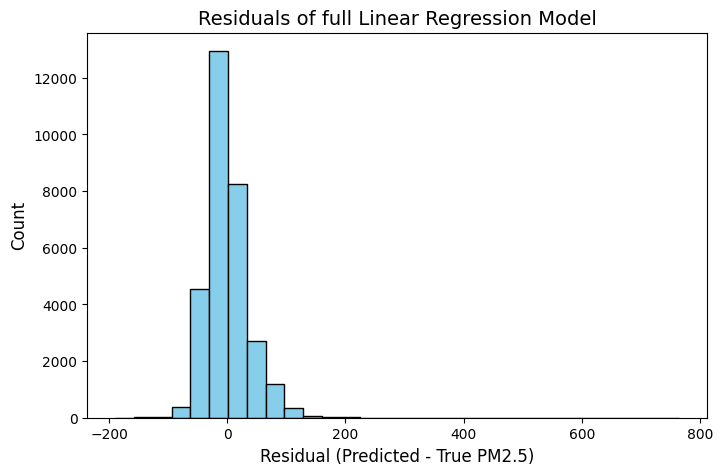

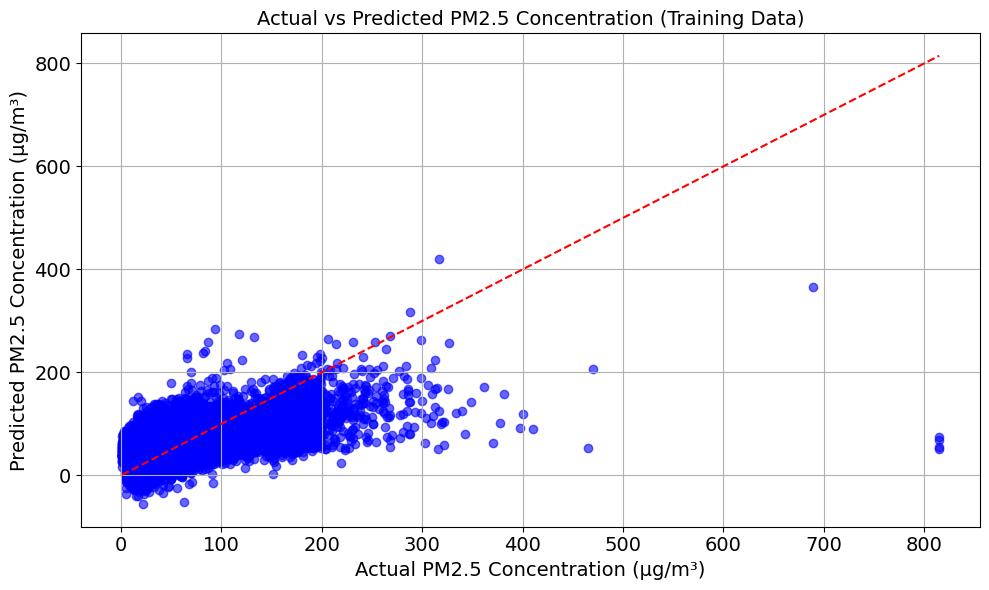

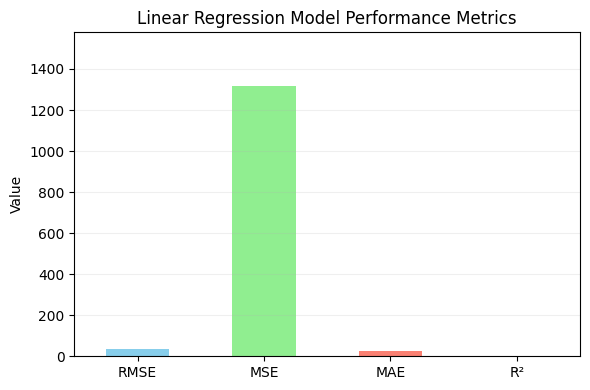

Feature Importance (Linear Regression Coefficients):
L3_NO2_stratospheric_NO2_column_number_density     311586.227523
L3_HCHO_tropospheric_HCHO_column_number_density    119149.958756
L3_NO2_NO2_slant_column_number_density             109589.753677
L3_NO2_NO2_column_number_density                    44226.239138
L3_SO2_SO2_slant_column_number_density               5645.345072
specific_humidity_2m_above_ground                    1216.079222
L3_CO_CO_column_number_density                       1002.152298
L3_SO2_SO2_column_number_density                      632.936232
L3_HCHO_cloud_fraction                                 42.346010
L3_SO2_SO2_column_number_density_amf                   13.232681
dtype: float64


In [224]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load X_train and X_test (Make sure X_train contains 'target')
# -----------------------------
X_train = pd.read_csv('Train.csv', sep=',')  # Replace with your file path
X_test = pd.read_csv('Test.csv', sep=',')  # Replace with your file path
X_train = X_train.replace(0, np.nan)
# Set threshold for dropping columns (e.g., 60% missing)
threshold = 0.6

# Identify columns with >60% missing values
high_nan_cols = X_train.columns[X_train.isna().mean() > threshold]


# Drop those columns
X_train = X_train.drop(columns=high_nan_cols)
X_train = X_train.select_dtypes(include=[np.number])
# Fill remaining NaNs with median
X_train = X_train.fillna(X_train.mean())

# Select features (X) and target (y) for training
X_train_selected = X_train[['precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
       'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle',
       'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density',
       'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height',
       'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle',
       'L3_CO_sensor_zenith_angle', 'L3_CO_solar_azimuth_angle',
       'L3_CO_solar_zenith_angle', 'L3_HCHO_HCHO_slant_column_number_density',
       'L3_HCHO_cloud_fraction', 'L3_HCHO_sensor_azimuth_angle',
       'L3_HCHO_sensor_zenith_angle', 'L3_HCHO_solar_azimuth_angle',
       'L3_HCHO_solar_zenith_angle',
       'L3_HCHO_tropospheric_HCHO_column_number_density',
       'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
       'L3_CLOUD_cloud_base_height', 'L3_CLOUD_cloud_base_pressure',
       'L3_CLOUD_cloud_fraction', 'L3_CLOUD_cloud_optical_depth',
       'L3_CLOUD_cloud_top_height', 'L3_CLOUD_cloud_top_pressure',
       'L3_CLOUD_sensor_azimuth_angle', 'L3_CLOUD_sensor_zenith_angle',
       'L3_CLOUD_solar_azimuth_angle', 'L3_CLOUD_solar_zenith_angle',
       'L3_CLOUD_surface_albedo', 'L3_AER_AI_absorbing_aerosol_index',
       'L3_AER_AI_sensor_altitude', 'L3_AER_AI_sensor_azimuth_angle',
       'L3_AER_AI_sensor_zenith_angle', 'L3_AER_AI_solar_azimuth_angle',
       'L3_AER_AI_solar_zenith_angle', 'L3_SO2_SO2_column_number_density',
       'L3_SO2_SO2_column_number_density_amf',
       'L3_SO2_SO2_slant_column_number_density',
       'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction',
       'L3_SO2_sensor_azimuth_angle', 'L3_SO2_sensor_zenith_angle',
       'L3_SO2_solar_azimuth_angle', 'L3_SO2_solar_zenith_angle']]

y_train = X_train['target']  # Replace 'target' if necessary

# -----------------------------
# Fill missing values with mean for both X_train and X_test
# -----------------------------
X_train_selected = X_train_selected.fillna(X_train_selected.mean())
X_test_selected = X_test[['precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
       'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle',
       'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density',
       'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height',
       'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle',
       'L3_CO_sensor_zenith_angle', 'L3_CO_solar_azimuth_angle',
       'L3_CO_solar_zenith_angle', 'L3_HCHO_HCHO_slant_column_number_density',
       'L3_HCHO_cloud_fraction', 'L3_HCHO_sensor_azimuth_angle',
       'L3_HCHO_sensor_zenith_angle', 'L3_HCHO_solar_azimuth_angle',
       'L3_HCHO_solar_zenith_angle',
       'L3_HCHO_tropospheric_HCHO_column_number_density',
       'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
       'L3_CLOUD_cloud_base_height', 'L3_CLOUD_cloud_base_pressure',
       'L3_CLOUD_cloud_fraction', 'L3_CLOUD_cloud_optical_depth',
       'L3_CLOUD_cloud_top_height', 'L3_CLOUD_cloud_top_pressure',
       'L3_CLOUD_sensor_azimuth_angle', 'L3_CLOUD_sensor_zenith_angle',
       'L3_CLOUD_solar_azimuth_angle', 'L3_CLOUD_solar_zenith_angle',
       'L3_CLOUD_surface_albedo', 'L3_AER_AI_absorbing_aerosol_index',
       'L3_AER_AI_sensor_altitude', 'L3_AER_AI_sensor_azimuth_angle',
       'L3_AER_AI_sensor_zenith_angle', 'L3_AER_AI_solar_azimuth_angle',
       'L3_AER_AI_solar_zenith_angle', 'L3_SO2_SO2_column_number_density',
       'L3_SO2_SO2_column_number_density_amf',
       'L3_SO2_SO2_slant_column_number_density',
       'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction',
       'L3_SO2_sensor_azimuth_angle', 'L3_SO2_sensor_zenith_angle',
       'L3_SO2_solar_azimuth_angle', 'L3_SO2_solar_zenith_angle']]

X_test_selected = X_test_selected.fillna(X_test_selected.mean())

# -----------------------------
# Feature engineering for X_train
# -----------------------------
X_train_selected['temp_humidity'] = X_train_selected['temperature_2m_above_ground'] * X_train_selected['relative_humidity_2m_above_ground']
X_train_selected['wind_speed'] = np.sqrt(X_train_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_train_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Feature engineering for X_test
# -----------------------------
X_test_selected['temp_humidity'] = X_test_selected['temperature_2m_above_ground'] * X_test_selected['relative_humidity_2m_above_ground']
X_test_selected['wind_speed'] = np.sqrt(X_test_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_test_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Train linear regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_selected, y_train)

# -----------------------------
# Predict on training data
# -----------------------------
y_train_pred = model.predict(X_train_selected)

# -----------------------------
# Predict on X_test data (no target in X_test)
# -----------------------------
y_test_pred = model.predict(X_test_selected)

# -----------------------------
# Metrics for training data
# -----------------------------
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)  # RMSE
mse_train = mean_squared_error(y_train, y_train_pred)  # MSE
mae_train = mean_absolute_error(y_train, y_train_pred)  # MAE
r2_train = r2_score(y_train, y_train_pred)  # R²

# Print training metrics
print(f"Training Metrics:")
print(f"RMSE: {rmse_train:.2f}")
print(f"MSE: {mse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R²: {r2_train:.2f}")

# -----------------------------
# Residual histogram (for training data)
# -----------------------------
residuals = y_train - y_train_pred
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of full Linear Regression Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# Actual vs Predicted Plot for Training Data
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(y_train, y_train_pred, color='blue', label='Actual vs Predicted (Train)', alpha=0.6)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual PM2.5 Concentration (µg/m³)', fontsize=14)
plt.ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Actual vs Predicted PM2.5 Concentration (Training Data)', fontsize=14)
#plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Metrics Bar Plot for Training Data
# -----------------------------
metrics = pd.Series({'RMSE': rmse_train, 'MSE': mse_train, 'MAE': mae_train, 'R²': r2_train})
plt.figure(figsize=(6,4))
metrics.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title('Linear Regression Model Performance Metrics')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.ylim(0, max(metrics.max()*1.2, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# Feature Importance (Linear Regression coefficients)
# -----------------------------
importance = pd.Series(model.coef_, index=X_train_selected.columns).sort_values(ascending=False)
print("Feature Importance (Linear Regression Coefficients):")
print(importance.head(10))

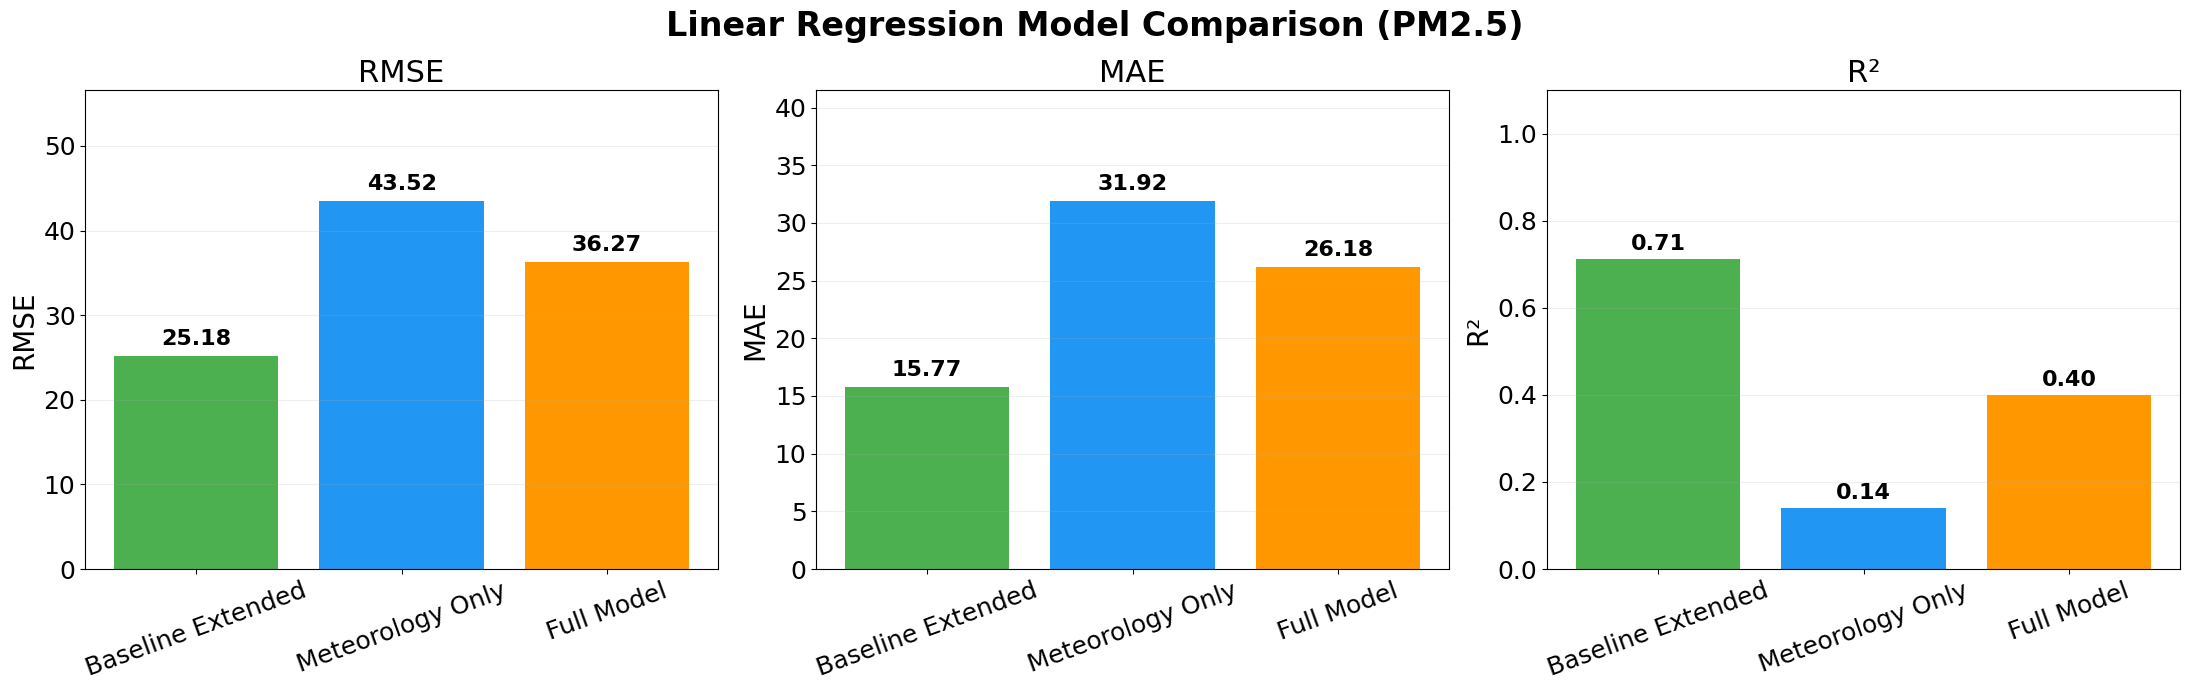

In [225]:
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Data
# ----------------------------
data = [
    {"Model": "Baseline Extended", "RMSE": 25.1799, "MAE": 15.7699, "R2": 0.7113},
    {"Model": "Meteorology Only", "RMSE": 43.52, "MAE": 31.92, "R2": 0.14},
    {"Model": "Full Model", "RMSE": 36.27, "MAE": 26.18, "R2": 0.40}
]

df = pd.DataFrame(data)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(22,7))

colors = ['#4CAF50', '#2196F3', '#FF9800']

# BIG fonts for PPT
axis_font = 20
tick_font = 18
title_font = 22

def add_labels(ax, values):
    for i, v in enumerate(values):
        ax.text(i, v + (max(values)*0.03), f"{v:.2f}",
                ha='center', fontsize=16, fontweight='bold')

# RMSE
axes[0].bar(df['Model'], df['RMSE'], color=colors)
axes[0].set_title('RMSE', fontsize=title_font)
axes[0].set_ylabel('RMSE', fontsize=axis_font)
axes[0].set_ylim(0, df['RMSE'].max()*1.3)
add_labels(axes[0], df['RMSE'])

# MAE
axes[1].bar(df['Model'], df['MAE'], color=colors)
axes[1].set_title('MAE', fontsize=title_font)
axes[1].set_ylabel('MAE', fontsize=axis_font)
axes[1].set_ylim(0, df['MAE'].max()*1.3)
add_labels(axes[1], df['MAE'])

# R²
axes[2].bar(df['Model'], df['R2'], color=colors)
axes[2].set_title('R²', fontsize=title_font)
axes[2].set_ylabel('R²', fontsize=axis_font)
axes[2].set_ylim(0, 1.1)
add_labels(axes[2], df['R2'])

#  FIX: Make axis tick labels BIG
for ax in axes:
    ax.tick_params(axis='x', labelsize=tick_font, rotation=20)
    ax.tick_params(axis='y', labelsize=tick_font)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Linear Regression Model Comparison (PM2.5)', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

## 1 Physics-Inspired PM2.5 Formula

We combine emissions, chemistry, and meteorology into a simplified model:

$$
\text{PM}_{2.5} =
\underbrace{\alpha_1 E}_{\text{primary emissions}}
+
\underbrace{\alpha_2 (SO_2 + NO_x + VOCs)}_{\text{secondary formation}}
+
\underbrace{\alpha_3 \cdot RH}_{\text{humidity effect}}
+
\underbrace{\alpha_4 \cdot T}_{\text{temperature effect}}
-
\underbrace{\alpha_5 \cdot W}_{\text{wind dispersion}}
+
\epsilon
$$

---

## 2 Interpretation

- **$E$ (Emissions)** → Direct pollution (traffic, industry, biomass burning)  
- **$SO_2, NO_x, VOCs$ (Chemical precursors)** → Form secondary particles (sulfates, nitrates, organic aerosols)  
- **$RH$ (Relative Humidity)** → Enhances particle formation → ↑ PM2.5  
- **$T$ (Temperature)** → Influences atmospheric chemical reactions  
- **$W$ (Wind Speed)** → Disperses pollutants → ↓ PM2.5  
- **$\epsilon$ (Error term)** → Noise, unknown sources, measurement uncertainty  

---

## 3 Emission Breakdown

$$
E = E_{\text{traffic}} + E_{\text{industry}} + E_{\text{biomass}} + E_{\text{other}}
$$

- **Traffic** → vehicles, urban congestion  
- **Industry** → factories, power plants  
- **Biomass** → burning, agriculture, wildfires  
- **Other** → dust, construction, natural sources  

---

## 4 Insight

This equation shows that PM2.5 is driven by:

- **Direct emissions (E)**  
- **Chemical transformation (SO₂, NOₓ, VOCs)**  
- **Meteorology (RH, T, W)**  


Training Metrics:
RMSE: 36.27
MSE: 1315.36
MAE: 26.18
R²: 0.40


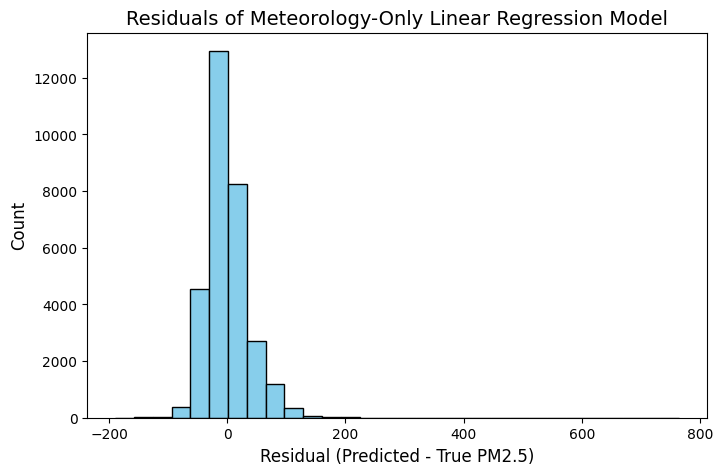

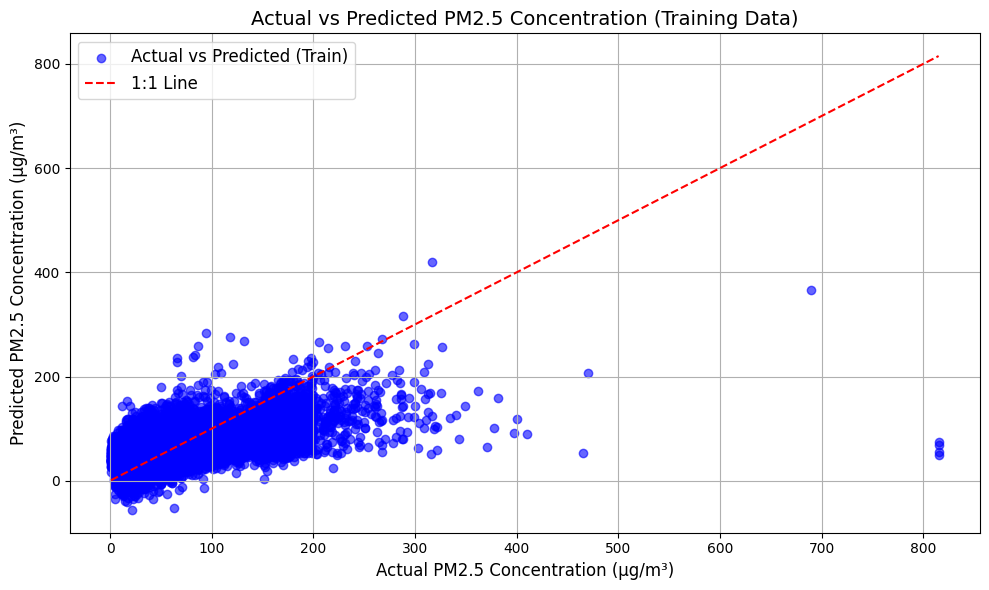

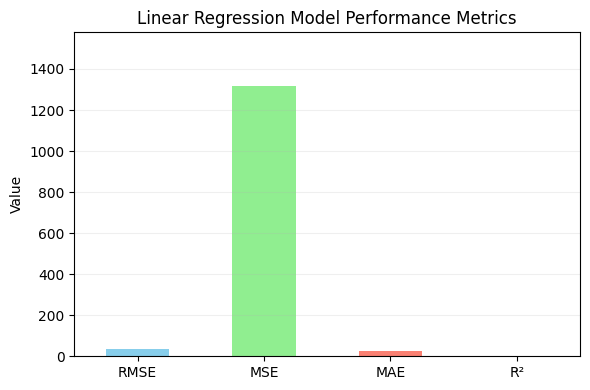

Feature Importance (Linear Regression Coefficients):
L3_NO2_stratospheric_NO2_column_number_density     311586.227523
L3_HCHO_tropospheric_HCHO_column_number_density    119149.958756
L3_NO2_NO2_slant_column_number_density             109589.753677
L3_NO2_NO2_column_number_density                    44226.239138
L3_SO2_SO2_slant_column_number_density               5645.345072
specific_humidity_2m_above_ground                    1216.079222
L3_CO_CO_column_number_density                       1002.152298
L3_SO2_SO2_column_number_density                      632.936232
L3_HCHO_cloud_fraction                                 42.346010
L3_SO2_SO2_column_number_density_amf                   13.232681
dtype: float64


In [226]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load X_train and X_test (Make sure X_train contains 'target')
# -----------------------------
X_train = pd.read_csv('Train.csv', sep=',')  # Replace with your file path
X_test = pd.read_csv('Test.csv', sep=',')  # Replace with your file path
X_train = X_train.replace(0, np.nan)
# Set threshold for dropping columns (e.g., 60% missing)
threshold = 0.6

# Identify columns with >60% missing values
high_nan_cols = X_train.columns[X_train.isna().mean() > threshold]


# Drop those columns
X_train = X_train.drop(columns=high_nan_cols)
X_train = X_train.select_dtypes(include=[np.number])
# Fill remaining NaNs with median
X_train = X_train.fillna(X_train.mean())
# Select features (X) and target (y) for training using the new list of features
X_train_selected = X_train[['precipitable_water_entire_atmosphere',
                            'relative_humidity_2m_above_ground',
                            'specific_humidity_2m_above_ground',
                            'temperature_2m_above_ground',
                            'u_component_of_wind_10m_above_ground',
                            'v_component_of_wind_10m_above_ground',
                            'L3_NO2_NO2_column_number_density',
                            'L3_NO2_NO2_slant_column_number_density',
                            'L3_NO2_absorbing_aerosol_index', 
                            'L3_NO2_cloud_fraction',
                            'L3_NO2_sensor_altitude', 
                            'L3_NO2_sensor_azimuth_angle',
                            'L3_NO2_sensor_zenith_angle', 
                            'L3_NO2_solar_azimuth_angle',
                            'L3_NO2_solar_zenith_angle',
                            'L3_NO2_stratospheric_NO2_column_number_density',
                            'L3_NO2_tropopause_pressure',
                            'L3_NO2_tropospheric_NO2_column_number_density',
                            'L3_O3_O3_column_number_density', 
                            'L3_O3_O3_effective_temperature',
                            'L3_O3_cloud_fraction', 
                            'L3_O3_sensor_azimuth_angle',
                            'L3_O3_sensor_zenith_angle', 
                            'L3_O3_solar_azimuth_angle',
                            'L3_O3_solar_zenith_angle', 
                            'L3_CO_CO_column_number_density',
                            'L3_CO_H2O_column_number_density', 
                            'L3_CO_cloud_height',
                            'L3_CO_sensor_altitude', 
                            'L3_CO_sensor_azimuth_angle',
                            'L3_CO_sensor_zenith_angle', 
                            'L3_CO_solar_azimuth_angle',
                            'L3_CO_solar_zenith_angle', 
                            'L3_HCHO_HCHO_slant_column_number_density',
                            'L3_HCHO_cloud_fraction', 
                            'L3_HCHO_sensor_azimuth_angle',
                            'L3_HCHO_sensor_zenith_angle', 
                            'L3_HCHO_solar_azimuth_angle',
                            'L3_HCHO_solar_zenith_angle',
                            'L3_HCHO_tropospheric_HCHO_column_number_density',
                            'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
                            'L3_CLOUD_cloud_base_height', 
                            'L3_CLOUD_cloud_base_pressure',
                            'L3_CLOUD_cloud_fraction', 
                            'L3_CLOUD_cloud_optical_depth',
                            'L3_CLOUD_cloud_top_height', 
                            'L3_CLOUD_cloud_top_pressure',
                            'L3_CLOUD_sensor_azimuth_angle', 
                            'L3_CLOUD_sensor_zenith_angle',
                            'L3_CLOUD_solar_azimuth_angle', 
                            'L3_CLOUD_solar_zenith_angle',
                            'L3_CLOUD_surface_albedo', 
                            'L3_AER_AI_absorbing_aerosol_index',
                            'L3_AER_AI_sensor_altitude', 
                            'L3_AER_AI_sensor_azimuth_angle',
                            'L3_AER_AI_sensor_zenith_angle', 
                            'L3_AER_AI_solar_azimuth_angle',
                            'L3_AER_AI_solar_zenith_angle', 
                            'L3_SO2_SO2_column_number_density',
                            'L3_SO2_SO2_column_number_density_amf',
                            'L3_SO2_SO2_slant_column_number_density',
                            'L3_SO2_absorbing_aerosol_index', 
                            'L3_SO2_cloud_fraction',
                            'L3_SO2_sensor_azimuth_angle', 
                            'L3_SO2_sensor_zenith_angle',
                            'L3_SO2_solar_azimuth_angle', 
                            'L3_SO2_solar_zenith_angle']]

y_train = X_train['target']  # Replace 'target' if necessary

# -----------------------------
# Fill missing values with mean for both X_train and X_test
# -----------------------------
X_train_selected = X_train_selected.fillna(X_train_selected.mean())
X_test_selected = X_test[['precipitable_water_entire_atmosphere',
                          'relative_humidity_2m_above_ground',
                          'specific_humidity_2m_above_ground',
                          'temperature_2m_above_ground',
                          'u_component_of_wind_10m_above_ground',
                          'v_component_of_wind_10m_above_ground',
                          'L3_NO2_NO2_column_number_density',
                          'L3_NO2_NO2_slant_column_number_density',
                          'L3_NO2_absorbing_aerosol_index', 
                          'L3_NO2_cloud_fraction',
                          'L3_NO2_sensor_altitude', 
                          'L3_NO2_sensor_azimuth_angle',
                          'L3_NO2_sensor_zenith_angle', 
                          'L3_NO2_solar_azimuth_angle',
                          'L3_NO2_solar_zenith_angle',
                          'L3_NO2_stratospheric_NO2_column_number_density',
                          'L3_NO2_tropopause_pressure',
                          'L3_NO2_tropospheric_NO2_column_number_density',
                          'L3_O3_O3_column_number_density', 
                          'L3_O3_O3_effective_temperature',
                          'L3_O3_cloud_fraction', 
                          'L3_O3_sensor_azimuth_angle',
                          'L3_O3_sensor_zenith_angle', 
                          'L3_O3_solar_azimuth_angle',
                          'L3_O3_solar_zenith_angle', 
                          'L3_CO_CO_column_number_density',
                          'L3_CO_H2O_column_number_density', 
                          'L3_CO_cloud_height',
                          'L3_CO_sensor_altitude', 
                          'L3_CO_sensor_azimuth_angle',
                          'L3_CO_sensor_zenith_angle', 
                          'L3_CO_solar_azimuth_angle',
                          'L3_CO_solar_zenith_angle', 
                          'L3_HCHO_HCHO_slant_column_number_density',
                          'L3_HCHO_cloud_fraction', 
                          'L3_HCHO_sensor_azimuth_angle',
                          'L3_HCHO_sensor_zenith_angle', 
                          'L3_HCHO_solar_azimuth_angle',
                          'L3_HCHO_solar_zenith_angle',
                          'L3_HCHO_tropospheric_HCHO_column_number_density',
                          'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
                          'L3_CLOUD_cloud_base_height', 
                          'L3_CLOUD_cloud_base_pressure',
                          'L3_CLOUD_cloud_fraction', 
                          'L3_CLOUD_cloud_optical_depth',
                          'L3_CLOUD_cloud_top_height', 
                          'L3_CLOUD_cloud_top_pressure',
                          'L3_CLOUD_sensor_azimuth_angle', 
                          'L3_CLOUD_sensor_zenith_angle',
                          'L3_CLOUD_solar_azimuth_angle', 
                          'L3_CLOUD_solar_zenith_angle',
                          'L3_CLOUD_surface_albedo', 
                          'L3_AER_AI_absorbing_aerosol_index',
                          'L3_AER_AI_sensor_altitude', 
                          'L3_AER_AI_sensor_azimuth_angle',
                          'L3_AER_AI_sensor_zenith_angle', 
                          'L3_AER_AI_solar_azimuth_angle',
                          'L3_AER_AI_solar_zenith_angle', 
                          'L3_SO2_SO2_column_number_density',
                          'L3_SO2_SO2_column_number_density_amf',
                          'L3_SO2_SO2_slant_column_number_density',
                          'L3_SO2_absorbing_aerosol_index', 
                          'L3_SO2_cloud_fraction',
                          'L3_SO2_sensor_azimuth_angle', 
                          'L3_SO2_sensor_zenith_angle',
                          'L3_SO2_solar_azimuth_angle', 
                          'L3_SO2_solar_zenith_angle']]

X_test_selected = X_test_selected.fillna(X_test_selected.mean())

# -----------------------------
# Feature engineering for X_train
# -----------------------------
X_train_selected['temp_humidity'] = X_train_selected['temperature_2m_above_ground'] * X_train_selected['relative_humidity_2m_above_ground']
X_train_selected['wind_speed'] = np.sqrt(X_train_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_train_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Feature engineering for X_test
# -----------------------------
X_test_selected['temp_humidity'] = X_test_selected['temperature_2m_above_ground'] * X_test_selected['relative_humidity_2m_above_ground']
X_test_selected['wind_speed'] = np.sqrt(X_test_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_test_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Train linear regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_selected, y_train)

# -----------------------------
# Predict on training data
# -----------------------------
y_train_pred = model.predict(X_train_selected)

# -----------------------------
# Predict on X_test data (no target in X_test)
# -----------------------------
y_test_pred = model.predict(X_test_selected)

# -----------------------------
# Metrics for training data
# -----------------------------
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)  # RMSE
mse_train = mean_squared_error(y_train, y_train_pred)  # MSE
mae_train = mean_absolute_error(y_train, y_train_pred)  # MAE
r2_train = r2_score(y_train, y_train_pred)  # R²

# Print training metrics
print(f"Training Metrics:")
print(f"RMSE: {rmse_train:.2f}")
print(f"MSE: {mse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R²: {r2_train:.2f}")

# -----------------------------
# Residual histogram (for training data)
# -----------------------------
residuals = y_train - y_train_pred
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Meteorology-Only Linear Regression Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# Actual vs Predicted Plot for Training Data
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(y_train, y_train_pred, color='blue', label='Actual vs Predicted (Train)', alpha=0.6)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=12)
plt.title('Actual vs Predicted PM2.5 Concentration (Training Data)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Metrics Bar Plot for Training Data
# -----------------------------
metrics = pd.Series({'RMSE': rmse_train, 'MSE': mse_train, 'MAE': mae_train, 'R²': r2_train})
plt.figure(figsize=(6,4))
metrics.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'orange'])
plt.title('Linear Regression Model Performance Metrics')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.ylim(0, max(metrics.max()*1.2, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# Feature Importance (Linear Regression coefficients)
# -----------------------------
importance = pd.Series(model.coef_, index=X_train_selected.columns).sort_values(ascending=False)
print("Feature Importance (Linear Regression Coefficients):")
print(importance.head(10))

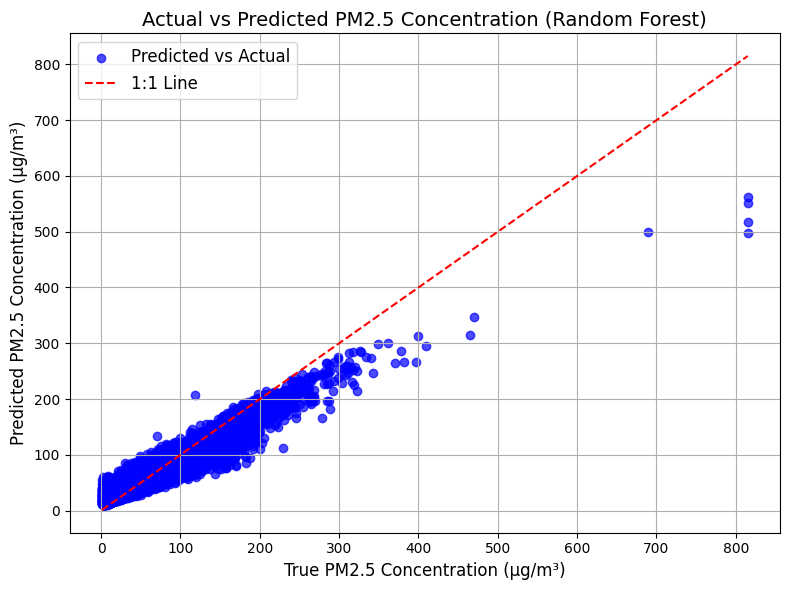

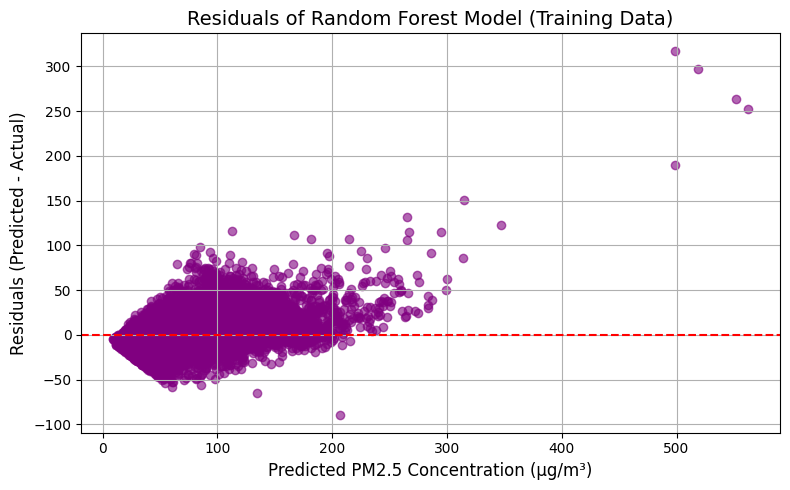

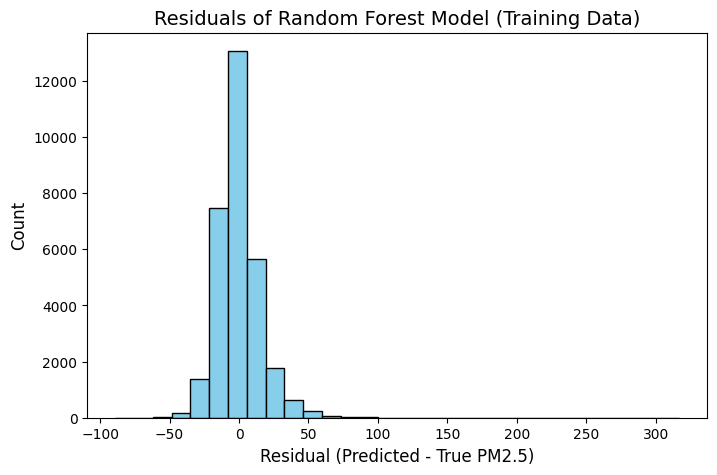

Top 10 Features by Importance:
L3_CO_CO_column_number_density                     0.209757
wind_speed                                         0.132855
L3_HCHO_tropospheric_HCHO_column_number_density    0.089520
temp_humidity                                      0.068036
temperature_2m_above_ground                        0.057700
L3_O3_O3_column_number_density                     0.057616
L3_AER_AI_absorbing_aerosol_index                  0.053763
L3_NO2_tropospheric_NO2_column_number_density      0.051769
relative_humidity_2m_above_ground                  0.045931
v_component_of_wind_10m_above_ground               0.043385
dtype: float64


In [227]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# -----------------------------
# Select features for training
# -----------------------------
meteorology = ['temperature_2m_above_ground',
               'precipitable_water_entire_atmosphere',
               'relative_humidity_2m_above_ground',
               'specific_humidity_2m_above_ground',
               'u_component_of_wind_10m_above_ground',
               'v_component_of_wind_10m_above_ground']

satellite = ['L3_NO2_tropospheric_NO2_column_number_density',
             'L3_CO_CO_column_number_density',
             'L3_O3_O3_column_number_density',
             'L3_HCHO_tropospheric_HCHO_column_number_density',
             'L3_SO2_SO2_column_number_density',
             'L3_AER_AI_absorbing_aerosol_index',
             'L3_CLOUD_cloud_fraction']

features = meteorology + satellite

# Select training data (X_train should already contain 'target')
X_train_selected = X_train[features].copy()
y_train = X_train['target'].copy()

# -----------------------------
# Fill missing values for both X_train and X_test
# -----------------------------
X_train_selected = X_train_selected.fillna(X_train_selected.mean())
X_test_selected = X_test[features].copy()
X_test_selected = X_test_selected.fillna(X_test_selected.mean())

# -----------------------------
# Feature engineering for X_train
# -----------------------------
X_train_selected['temp_humidity'] = X_train_selected['temperature_2m_above_ground'] * X_train_selected['relative_humidity_2m_above_ground']
X_train_selected['wind_speed'] = np.sqrt(X_train_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_train_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Feature engineering for X_test
# -----------------------------
X_test_selected['temp_humidity'] = X_test_selected['temperature_2m_above_ground'] * X_test_selected['relative_humidity_2m_above_ground']
X_test_selected['wind_speed'] = np.sqrt(X_test_selected['u_component_of_wind_10m_above_ground']**2 + 
                                         X_test_selected['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# Train Random Forest Regressor
# -----------------------------
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train_selected, y_train)

# Predict on training data (optional but for consistency)
y_train_pred = rf.predict(X_train_selected)

# Predict on test data (since no target in X_test)
y_test_pred = rf.predict(X_test_selected)

# -----------------------------
# Visualizing the predicted values vs actual values (for training data)
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.7, label='Predicted vs Actual')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('True PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=12)
plt.title('Actual vs Predicted PM2.5 Concentration (Random Forest)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Residual Plot for Training Data
# -----------------------------
residuals_train = y_train - y_train_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, residuals_train, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Residuals (Predicted - Actual)', fontsize=12)
plt.title('Residuals of Random Forest Model (Training Data)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Residual Histogram for Training Data
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(residuals_train, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Random Forest Model (Training Data)", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importances = pd.Series(rf.feature_importances_, index=X_train_selected.columns).sort_values(ascending=False)
print("Top 10 Features by Importance:")
print(importances.head(10))

In [228]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------
# 1️⃣ CHECK INPUT
# ----------------------------
if X_train is None or X_test is None or y_train is None:
    raise ValueError("Make sure X_train, X_test, and y_train are loaded properly!")

train = X_train.copy()
test = X_test.copy()

# ----------------------------
# 2️⃣ FIX DATE (IMPORTANT)
# ----------------------------
def extract_date(df):
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    elif 'place_id' in df.columns:
        df['Date'] = df['place_id'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0]
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    else:
        df['Date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='D')
    return df

train = extract_date(train)
test = extract_date(test)

# Sort by date
train = train.sort_values('Date').reset_index(drop=True)
test = test.sort_values('Date').reset_index(drop=True)

# ----------------------------
# 3️⃣ DROP USELESS COLUMNS
# ----------------------------
drop_cols = ['place_id', 'target_max', 'target_min', 'target_var', 'trat_count']
train.drop(columns=drop_cols, inplace=True, errors='ignore')
test.drop(columns=drop_cols, inplace=True, errors='ignore')

# ----------------------------
# 4️⃣ FEATURES
# ----------------------------
meteorology = [
    'temperature_2m_above_ground',
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'specific_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
]

satellite = [
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_CO_CO_column_number_density',
    'L3_O3_O3_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density',
    'L3_SO2_SO2_column_number_density',
    'L3_AER_AI_absorbing_aerosol_index',
    'L3_CLOUD_cloud_fraction'
]

features = meteorology + satellite

# Keep only existing columns (prevents KeyError)
features = [f for f in features if f in train.columns]

X_train_features = train[features].copy()
X_test_features = test[features].copy()

# ----------------------------
#  FEATURE ENGINEERING
# ----------------------------
for df in [X_train_features, X_test_features]:
    df['temp_humidity'] = df['temperature_2m_above_ground'] * df['relative_humidity_2m_above_ground']
    df['wind_speed'] = np.sqrt(
        df['u_component_of_wind_10m_above_ground']**2 +
        df['v_component_of_wind_10m_above_ground']**2
    )

# ----------------------------
# CLEAN NUMERIC
# ----------------------------
X_train_features = X_train_features.apply(pd.to_numeric, errors='coerce')
X_test_features = X_test_features.apply(pd.to_numeric, errors='coerce')

X_train_features.fillna(X_train_features.mean(), inplace=True)
X_test_features.fillna(X_train_features.mean(), inplace=True)

# ----------------------------
#  TRAIN MODEL
# ----------------------------
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train_features, y_train)

# ----------------------------
#  PREDICT
# ----------------------------
y_train_pred = rf.predict(X_train_features)
y_future_pred = rf.predict(X_test_features)

# ----------------------------
#  METRICS
# ----------------------------
rmse = mean_squared_error(y_train, y_train_pred, squared=False)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print(f"Training Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# ----------------------------
# CLEAN DATE AXIS
# ----------------------------
train_dates = train['Date']
test_dates = test['Date']



# ----------------------------
#  FEATURE IMPORTANCE
# ----------------------------
importances = pd.Series(rf.feature_importances_, index=X_train_features.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 10 Features:")
print(importances.head(10))

Training Metrics -> RMSE: 15.53, MAE: 11.10, R²: 0.89

Top 10 Features:
L3_CO_CO_column_number_density                     0.209757
wind_speed                                         0.132855
L3_HCHO_tropospheric_HCHO_column_number_density    0.089520
temp_humidity                                      0.068036
temperature_2m_above_ground                        0.057700
L3_O3_O3_column_number_density                     0.057616
L3_AER_AI_absorbing_aerosol_index                  0.053763
L3_NO2_tropospheric_NO2_column_number_density      0.051769
relative_humidity_2m_above_ground                  0.045931
v_component_of_wind_10m_above_ground               0.043385
dtype: float64


Training Metrics -> RMSE: 13.41, MAE: 9.57, R²: 0.92


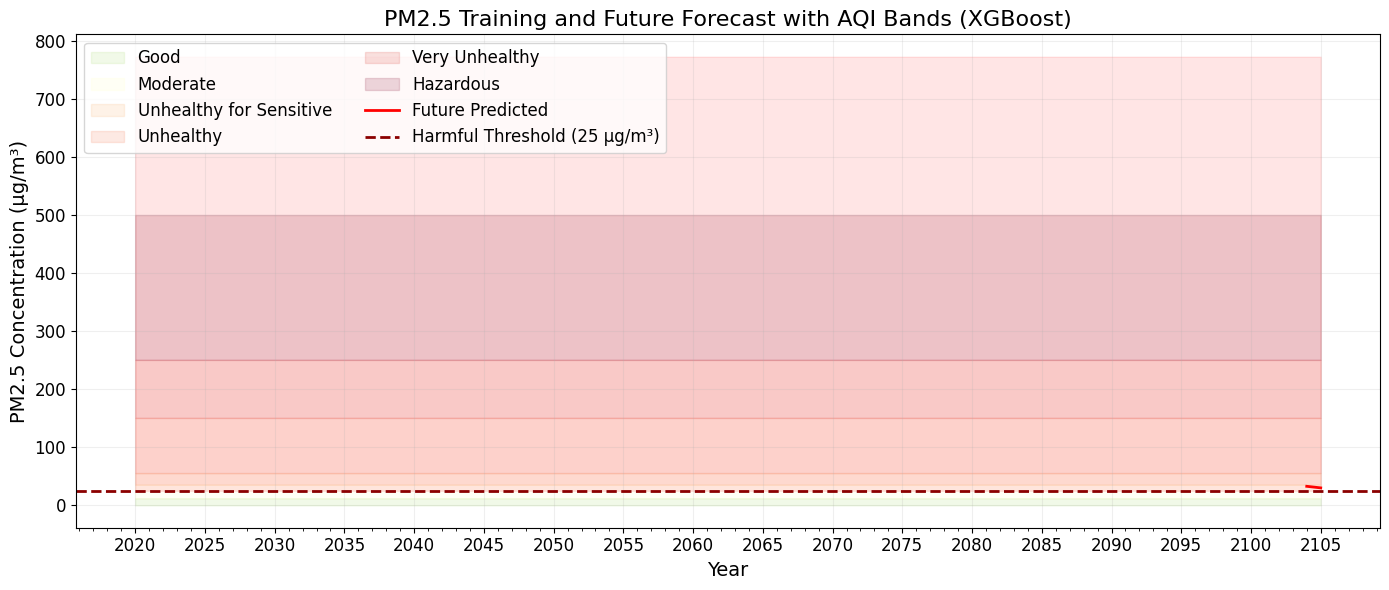

Top 10 Features by Importance:
L3_CO_CO_column_number_density                     0.168572
wind_speed                                         0.114700
L3_HCHO_tropospheric_HCHO_column_number_density    0.107491
temp_humidity                                      0.093726
L3_NO2_tropospheric_NO2_column_number_density      0.070070
L3_O3_O3_column_number_density                     0.058225
L3_AER_AI_absorbing_aerosol_index                  0.050805
L3_CLOUD_cloud_fraction                            0.049441
specific_humidity_2m_above_ground                  0.048796
v_component_of_wind_10m_above_ground               0.047480
dtype: float32


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ----------------------------
#  Assume X_train, X_test, y_train are loaded
# ----------------------------
train = X_train.copy()
test = X_test.copy()

# ----------------------------
#  Select features
# ----------------------------
meteorology = ['temperature_2m_above_ground',
               'precipitable_water_entire_atmosphere',
               'relative_humidity_2m_above_ground',
               'specific_humidity_2m_above_ground',
               'u_component_of_wind_10m_above_ground',
               'v_component_of_wind_10m_above_ground']

satellite = ['L3_NO2_tropospheric_NO2_column_number_density',
             'L3_CO_CO_column_number_density',
             'L3_O3_O3_column_number_density',
             'L3_HCHO_tropospheric_HCHO_column_number_density',
             'L3_SO2_SO2_column_number_density',
             'L3_AER_AI_absorbing_aerosol_index',
             'L3_CLOUD_cloud_fraction']

features = [f for f in meteorology + satellite if f in train.columns]

X_train_features = train[features].copy()
X_test_features = test[features].copy()

# ----------------------------
# Feature engineering
# ----------------------------
for df in [X_train_features, X_test_features]:
    df['temp_humidity'] = df['temperature_2m_above_ground'] * df['relative_humidity_2m_above_ground']
    df['wind_speed'] = np.sqrt(df['u_component_of_wind_10m_above_ground']**2 +
                               df['v_component_of_wind_10m_above_ground']**2)

# ----------------------------
#  Fill missing
# ----------------------------
X_train_features = X_train_features.apply(pd.to_numeric, errors='coerce').fillna(X_train_features.mean())
X_test_features = X_test_features.apply(pd.to_numeric, errors='coerce').fillna(X_test_features.mean())

# ----------------------------
#  Train XGBoost
# ----------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train_features, y_train)

# ----------------------------
# Predictions
# ----------------------------
y_train_pred = xgb_model.predict(X_train_features)
y_future_pred = xgb_model.predict(X_test_features)

# ----------------------------
#  Training metrics
# ----------------------------
rmse = mean_squared_error(y_train, y_train_pred, squared=False)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)
print(f"Training Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")



# ----------------------------
#  Feature importance
# ----------------------------
importances = pd.Series(xgb_model.feature_importances_, index=X_train_features.columns).sort_values(ascending=False)
print("Top 10 Features by Importance:")
print(importances.head(10))

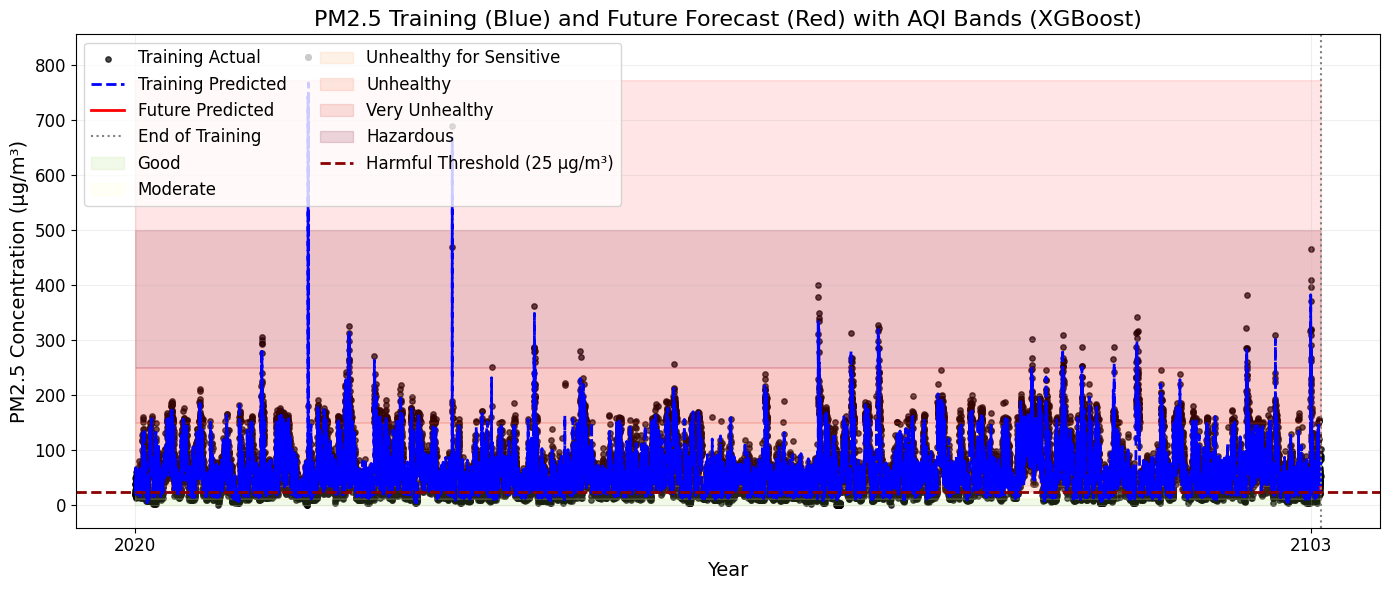

In [247]:
# ----------------------------
# Plot: Training 2020 + Future Forecast (clean x-axis)
# ----------------------------
plt.figure(figsize=(14,6))

# Training: blue line only in 2020
train_dates_plot = pd.to_datetime(train['Date']) if 'Date' in train.columns else pd.date_range(start="2020-01-01", periods=len(y_train), freq='D')
plt.scatter(train_dates_plot, y_train, color='black', s=15, alpha=0.7, label='Training Actual')
plt.plot(train_dates_plot, y_train_pred, color='blue', linestyle='--', linewidth=2, label='Training Predicted')

# Future: red line after 2020
future_start = train_dates_plot.max() + pd.Timedelta(days=1)
future_dates_plot = pd.date_range(start=future_start, periods=len(y_future_pred), freq='D')
plt.plot(future_dates_plot, y_future_pred, color='red', linewidth=2, label='Future Predicted')

# Vertical line separating training from future
plt.axvline(train_dates_plot.max(), color='gray', linestyle=':', linewidth=1.5, label='End of Training')

# AQI Bands
all_dates = pd.concat([pd.Series(train_dates_plot), pd.Series(future_dates_plot)])
for label, (low, high, color) in aqi_bands.items():
    plt.fill_between(all_dates, low, high, color=color, alpha=0.15, label=label)

# Harmful threshold
harmful_level = 25
plt.axhline(harmful_level, color='darkred', linestyle='--', linewidth=2,
            label=f'Harmful Threshold ({harmful_level} µg/m³)')
plt.fill_between(all_dates, harmful_level,
                 max(max(y_train_pred), max(y_future_pred), harmful_level) + 5,
                 color='red', alpha=0.1)

# Clean X-axis: show only 2020, then every 5th year for future
x_ticks_years = [2020]  # first year = training
future_years = pd.to_datetime(future_dates_plot).year.unique()
# pick every 5th year for ticks
x_ticks_years += list(future_years[::5])
x_ticks_dates = [pd.Timestamp(f"{y}-01-01") for y in x_ticks_years]

plt.xticks(x_ticks_dates, [str(y) for y in x_ticks_years], rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.title('PM2.5 Training (Blue) and Future Forecast (Red) with AQI Bands (XGBoost)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.legend(fontsize=12, ncol=2, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# 1️ Assume X_train, X_test, y_train are loaded
# ----------------------------
train = X_train.copy()
test = X_test.copy()

# ----------------------------
# 2 Select features
# ----------------------------
meteorology = ['temperature_2m_above_ground',
               'precipitable_water_entire_atmosphere',
               'relative_humidity_2m_above_ground',
               'specific_humidity_2m_above_ground',
               'u_component_of_wind_10m_above_ground',
               'v_component_of_wind_10m_above_ground']

satellite = ['L3_NO2_tropospheric_NO2_column_number_density',
             'L3_CO_CO_column_number_density',
             'L3_O3_O3_column_number_density',
             'L3_HCHO_tropospheric_HCHO_column_number_density',
             'L3_SO2_SO2_column_number_density',
             'L3_AER_AI_absorbing_aerosol_index',
             'L3_CLOUD_cloud_fraction']

features = [f for f in meteorology + satellite if f in train.columns]

X_train_features = train[features].copy()
X_test_features = test[features].copy()

# ----------------------------
#  Feature engineering
# ----------------------------
for df in [X_train_features, X_test_features]:
    df['temp_humidity'] = df['temperature_2m_above_ground'] * df['relative_humidity_2m_above_ground']
    df['wind_speed'] = np.sqrt(df['u_component_of_wind_10m_above_ground']**2 +
                               df['v_component_of_wind_10m_above_ground']**2)

# ----------------------------
#  Fill missing
# ----------------------------
X_train_features = X_train_features.apply(pd.to_numeric, errors='coerce').fillna(X_train_features.mean())
X_test_features = X_test_features.apply(pd.to_numeric, errors='coerce').fillna(X_test_features.mean())

# ----------------------------
#  Train Gradient Boosting
# ----------------------------
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    random_state=42
)

gbr_model.fit(X_train_features, y_train)

# ----------------------------
#  Predictions
# ----------------------------
y_train_pred = gbr_model.predict(X_train_features)
y_future_pred = gbr_model.predict(X_test_features)

# ----------------------------
#  Training metrics
# ----------------------------
rmse = mean_squared_error(y_train, y_train_pred, squared=False)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)
print(f"Training Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")



# ----------------------------
#  Feature importance
# ----------------------------
importances = pd.Series(gbr_model.feature_importances_, index=X_train_features.columns).sort_values(ascending=False)
print("Top 10 Features by Importance:")
print(importances.head(10))

Training Metrics -> RMSE: 14.24, MAE: 10.67, R²: 0.91
Top 10 Features by Importance:
L3_CO_CO_column_number_density                     0.196453
wind_speed                                         0.127386
L3_HCHO_tropospheric_HCHO_column_number_density    0.084540
temp_humidity                                      0.067278
L3_O3_O3_column_number_density                     0.064195
temperature_2m_above_ground                        0.062454
L3_AER_AI_absorbing_aerosol_index                  0.053768
relative_humidity_2m_above_ground                  0.053110
L3_CLOUD_cloud_fraction                            0.049103
L3_NO2_tropospheric_NO2_column_number_density      0.047763
dtype: float64


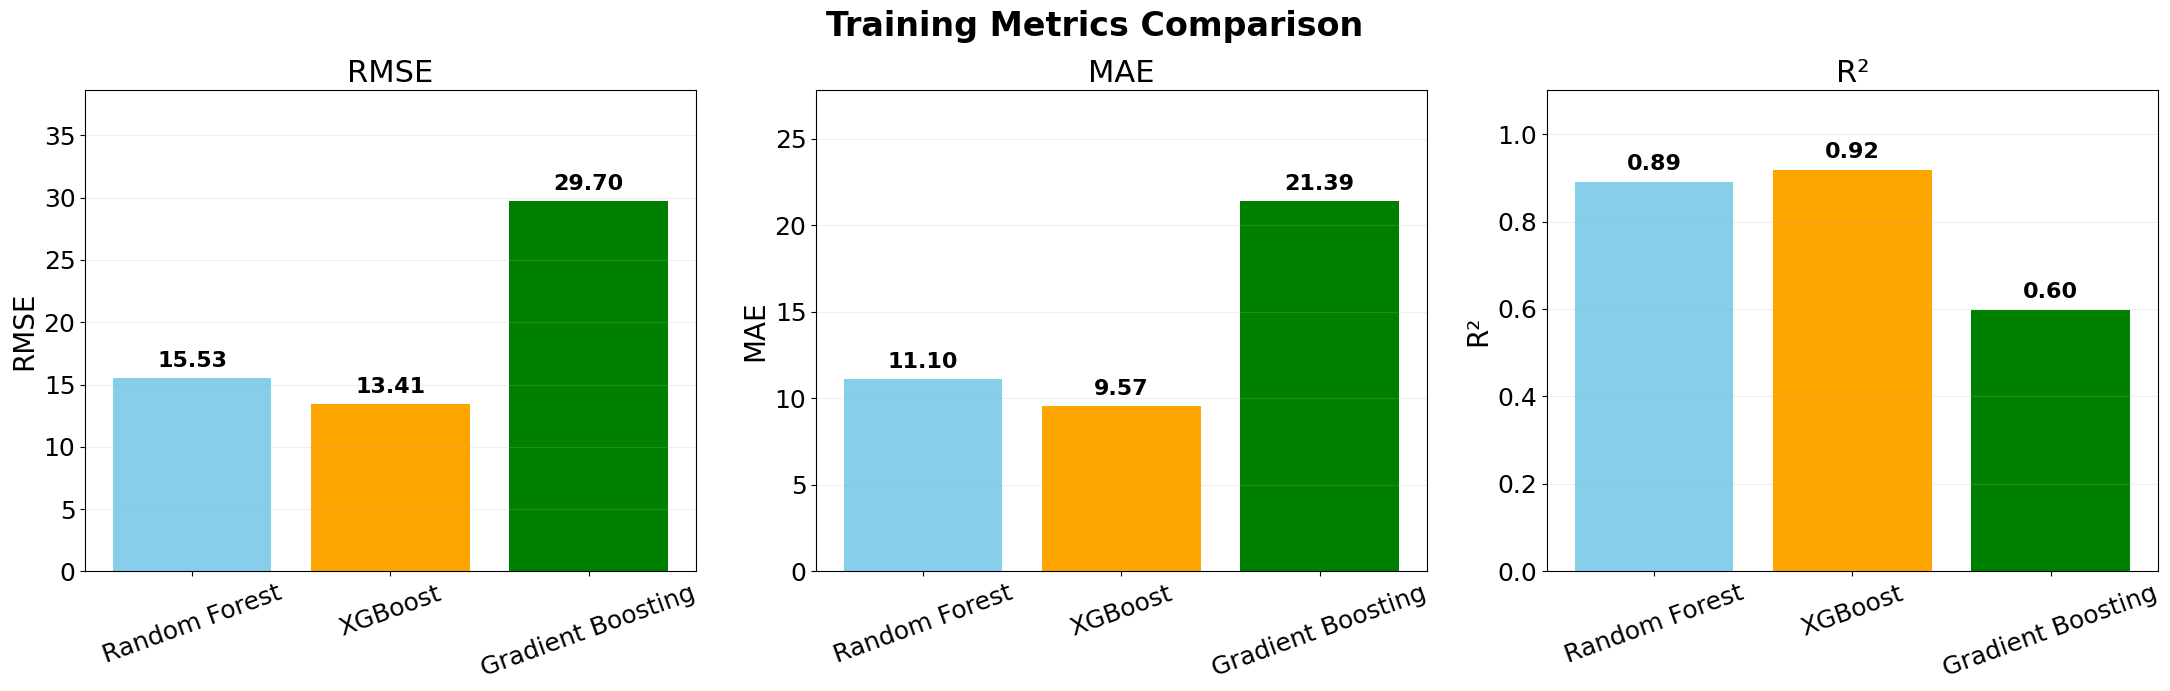

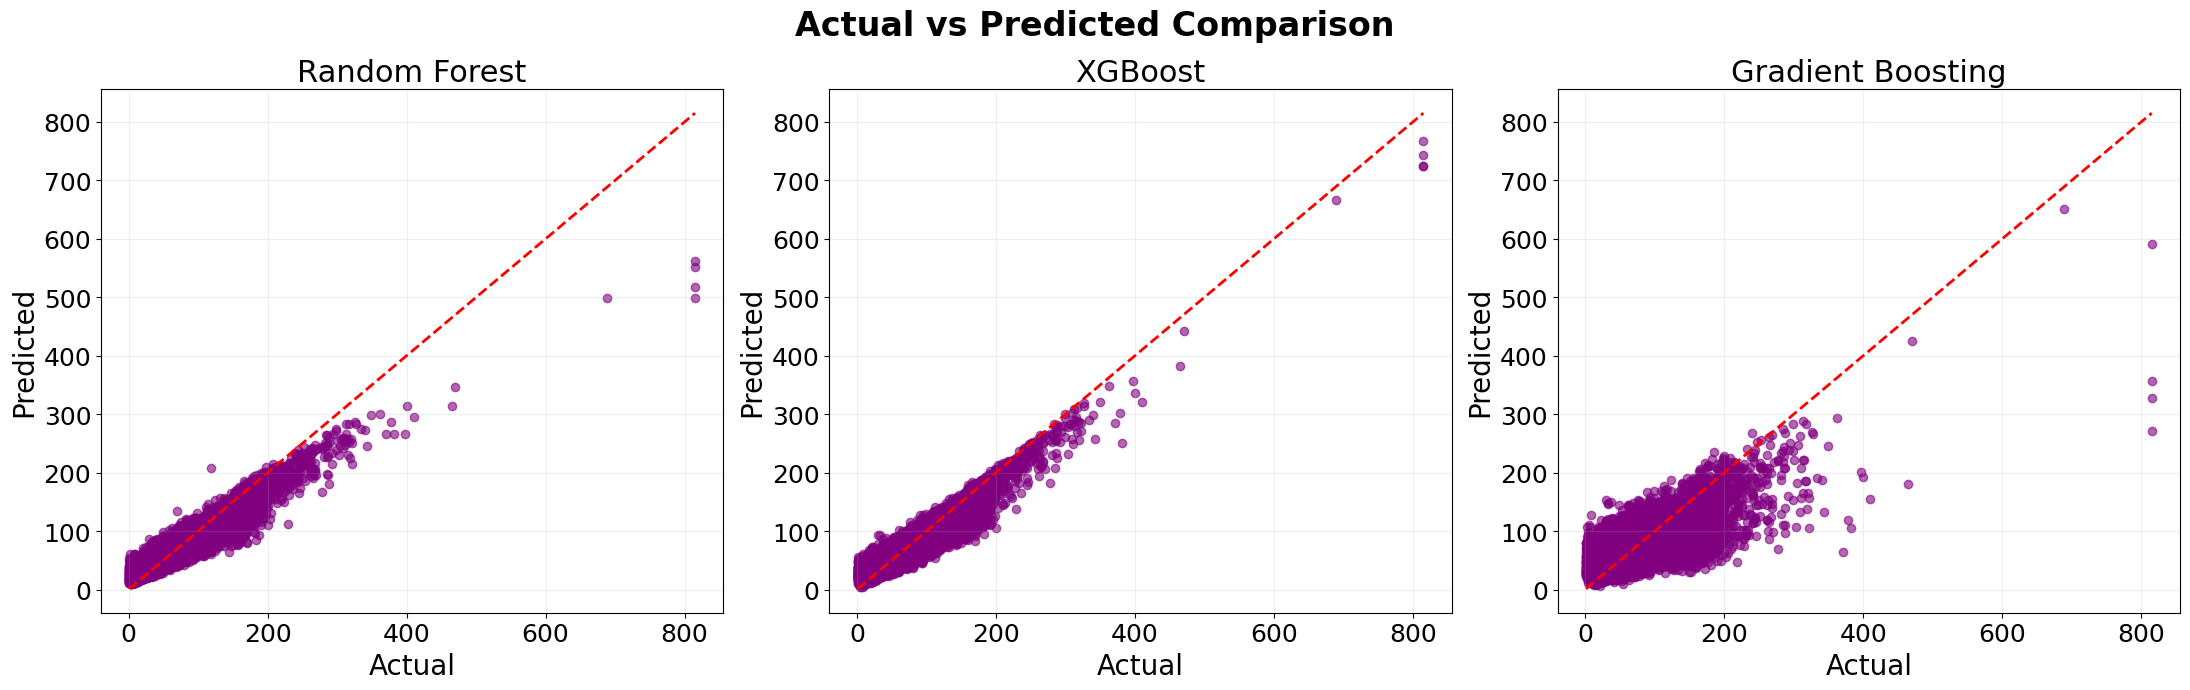

In [263]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# Models
# ----------------------------
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=10, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:squarederror', random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=5, subsample=0.8,
                                                   random_state=42)
}

metrics_summary = []

# Train models
y_preds = {}
for name, model in models.items():
    model.fit(X_train_features, y_train)
    y_pred = model.predict(X_train_features)
    y_preds[name] = y_pred
    rmse = mean_squared_error(y_train, y_pred, squared=False)
    mae = mean_absolute_error(y_train, y_pred)
    r2 = r2_score(y_train, y_pred)
    metrics_summary.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

metrics_df = pd.DataFrame(metrics_summary)

# ----------------------------
#  FONT SETTINGS
# ----------------------------
axis_font = 20
tick_font = 18
title_font = 22
value_font = 16

def add_labels(ax, values):
    for i, v in enumerate(values):
        ax.text(i, v + (max(values)*0.03), f"{v:.2f}",
                ha='center', fontsize=value_font, fontweight='bold')

# ----------------------------
# Metrics bar plots
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(22,7))
colors = ['skyblue','orange','green']

# RMSE
axes[0].bar(metrics_df['Model'], metrics_df['RMSE'], color=colors)
axes[0].set_title('RMSE', fontsize=title_font)
axes[0].set_ylabel('RMSE', fontsize=axis_font)
axes[0].set_ylim(0, metrics_df['RMSE'].max()*1.3)
add_labels(axes[0], metrics_df['RMSE'])

# MAE
axes[1].bar(metrics_df['Model'], metrics_df['MAE'], color=colors)
axes[1].set_title('MAE', fontsize=title_font)
axes[1].set_ylabel('MAE', fontsize=axis_font)
axes[1].set_ylim(0, metrics_df['MAE'].max()*1.3)
add_labels(axes[1], metrics_df['MAE'])

# R²
axes[2].bar(metrics_df['Model'], metrics_df['R2'], color=colors)
axes[2].set_title('R²', fontsize=title_font)
axes[2].set_ylabel('R²', fontsize=axis_font)
axes[2].set_ylim(0, 1.1)
add_labels(axes[2], metrics_df['R2'])

#  BIG ticks
for ax in axes:
    ax.tick_params(axis='x', labelsize=tick_font, rotation=20)
    ax.tick_params(axis='y', labelsize=tick_font)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Training Metrics Comparison', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

# ----------------------------
# Actual vs Predicted plots
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(22,7))

for ax, (name, y_pred) in zip(axes, y_preds.items()):
    ax.scatter(y_train, y_pred, alpha=0.6, color='purple')
    ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
            'r--', lw=2)

    ax.set_title(name, fontsize=title_font)
    ax.set_xlabel('Actual', fontsize=axis_font)
    ax.set_ylabel('Predicted', fontsize=axis_font)

    ax.tick_params(axis='x', labelsize=tick_font)
    ax.tick_params(axis='y', labelsize=tick_font)

    ax.grid(alpha=0.2)

plt.suptitle('Actual vs Predicted Comparison', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()